# 04. Text Preprocessing + Baseline Models

The notebook now compares three levels of text representation:

1. tokenized + padded sequence input,
2. TF-IDF/SVD lexical features,
3. turn-level semantic embeddings.

The notebook runs on the unified preprocessed data and saves intermediate features, model scores, tables, and plots so later notebooks can compare results without rerunning everything.


## 4.1 Model Plan

| Stage | Representation | Model | Purpose | Comment / Limitation |
|---|---|---|---|---|
| 1 | `tokenization + padding` | `One-Class SVM` | Test whether raw padded token positions plus side features contain anomaly signal. | Sequence-like input, but raw token IDs have weak semantic meaning. |
| 2 | `tokenization + padding` | `VAE mask vs no-mask` | Test whether ignoring padded positions in reconstruction loss improves VAE anomaly scoring. | Useful diagnostic for future sequence models, but still not a full Transformer/RNN. |
| 3 | `TF-IDF + SVD + side features` | `One-Class SVM` | Check whether lexical/tool words plus explicit length features can define a benign region. | Cheap benign-only baseline, but weak on semantic meaning and turn order. |
| 4 | `turn embedding pooling + side features` | `One-Class SVM` | Check whether semantic turn embeddings improve the benign-only baseline. | Better semantic signal, but pooling still weakens order and local suspicious turns. |
| 5 | `TF-IDF + SVD + side features` | `VAE` | Test whether reconstruction-based anomaly modeling improves the lexical representation. | Course-aligned and stable, but still fixed-vector. |
| 6 | `turn embedding pooling + side features` | `VAE` | Test whether VAE benefits from stronger semantic representation. | More expensive because turn embeddings must be computed. |

Important SVM clarification:

- `Linear SVM` is supervised and needs hacked labels during training. That is not our main benign-only setup.
- `One-Class SVM` is the SVM version that matches our setup: train only on benign SWE-smith and score TRACE/MALT as potential anomalies.
- The purpose of One-Class SVM is not to replace VAE. It is a simple baseline to show whether the representation already contains anomaly signal before adding a neural model.


## 4.2 Data Reading and Three Text Representations

Default behavior:

- Read the already preprocessed files from `02_preprocess_data.ipynb`.
- Train only on SWE-smith benign trajectories.
- Evaluate on TRACE and filtered manually reviewed MALT labels.

The three tested representations are:

1. `Tokenization + padding`: sequence-like token input with mask vs no-mask VAE reconstruction.
2. `TF-IDF + SVD + side features`: lexical/tool-action representation plus trajectory statistics.
3. `Turn embedding pooling + side features`: semantic turn-level embedding representation plus trajectory statistics.


In [69]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

import joblib

SEED = 1090
np.random.seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SWE_PARQUET_PATH = ROOT / "data" / "swe_train_unified.parquet"
TRACE_PARQUET_PATH = ROOT / "data" / "trace_unified.parquet"
FILTERED_MALT_PATH = ROOT / "data" / "clean" / "normalized_malt.jsonl"
USE_FILTERED_MALT = True
RUN_TURN_EMBEDDING_REPRESENTATION = True  # Keep main run from getting stuck on full-data embeddings.

FEATURE_DIR = ROOT / "results" / "features" / "04_text_preprocessing_baselines"
RESULT_DIR = ROOT / "results" / "modeling" / "04_text_preprocessing_baselines"
TABLE_DIR = ROOT / "results" / "tables" / "04_text_preprocessing_baselines"
FIG_DIR = ROOT / "results" / "figures" / "04_text_preprocessing_baselines"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SWE_PARQUET_PATH, TRACE_PARQUET_PATH


(WindowsPath('c:/Users/Hao/Dropbox/HES/CSCI E-109B Advanced Data Science/Final Project/detecting_reward_hacking/data/swe_train_unified.parquet'),
 WindowsPath('c:/Users/Hao/Dropbox/HES/CSCI E-109B Advanced Data Science/Final Project/detecting_reward_hacking/data/trace_unified.parquet'))

In [70]:
def parse_turns(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return []
    if isinstance(raw, list):
        return raw
    try:
        obj = json.loads(raw)
    except Exception:
        return []
    return obj if isinstance(obj, list) else []


def choose_turn_source(row):
    raw = row.get("turns")
    if raw is not None and not (isinstance(raw, float) and np.isnan(raw)):
        return raw
    return row.get("turns_json")


def turns_to_text(turns):
    parts = []
    for t in turns:
        if isinstance(t, dict):
            role = t.get("role", "unknown")
            text = t.get("text", t.get("content", ""))
            parts.append(f"[{role}] {text}")
        elif isinstance(t, (list, tuple)) and len(t) >= 2:
            parts.append(f"[{t[0]}] {t[1]}")
        else:
            parts.append(str(t))
    return "\n".join(parts)


def normalize_unified_parquet(path, dataset_name):
    df = pd.read_parquet(path)
    df["dataset"] = dataset_name

    if "turns" not in df.columns:
        df["turns"] = None
    if "turns_json" not in df.columns:
        df["turns_json"] = None
    if "flat_text" not in df.columns:
        df["flat_text"] = None

    # Avoid pandas Arrow where() on huge strings; build text as plain Python object series.
    text_values = []
    for _, row in df.iterrows():
        flat = row.get("flat_text")
        if isinstance(flat, str) and flat:
            text_values.append(flat)
        else:
            text_values.append(turns_to_text(parse_turns(choose_turn_source(row))))

    out = pd.DataFrame({
        "dataset": dataset_name,
        "trajectory_id": df["trajectory_id"].astype(str),
        "binary_label": df["is_hacked"].astype(int),
        "label_raw": df.get("label_raw", pd.Series([None] * len(df))).astype(str),
        "text": text_values,
        "turns": df["turns"].astype(object),
        "turns_json": df["turns_json"].astype(object),
        "n_turns": df["n_turns"].fillna(0).astype(int),
    })
    out["approx_tokens"] = out["text"].str.split().str.len().fillna(0).astype(int)
    return out


def load_filtered_malt(path=FILTERED_MALT_PATH):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            turns = obj.get("turns") or []
            text = obj.get("text") or turns_to_text(turns)
            rows.append({
                "dataset": "malt",
                "trajectory_id": obj.get("trajectory_id"),
                "binary_label": int(obj.get("binary_label", 0)),
                "label_raw": obj.get("raw_label"),
                "text": text,
                "turns": json.dumps(turns, ensure_ascii=False),
                "turns_json": None,
                "n_turns": int(obj.get("n_turns", len(turns))),
                "approx_tokens": len(text.split()),
            })
    return pd.DataFrame(rows)


swe_df = normalize_unified_parquet(SWE_PARQUET_PATH, "swe_smith").reset_index(drop=True)
trace_df = normalize_unified_parquet(TRACE_PARQUET_PATH, "trace").reset_index(drop=True)
if USE_FILTERED_MALT:
    malt_df = load_filtered_malt().reset_index(drop=True)
else:
    raise ValueError("Full MALT is intentionally disabled in this notebook version. Use filtered MALT for the main run.")

df = pd.concat([swe_df, trace_df, malt_df], ignore_index=True)

print("all:", df.shape)
print("swe:", swe_df.shape)
print("trace:", trace_df.shape, trace_df["binary_label"].value_counts().to_dict())
print("malt:", malt_df.shape, malt_df["binary_label"].value_counts().to_dict())

df.groupby(["dataset", "binary_label"]).size().rename("n").reset_index()

all: (27349, 9)
swe: (26076, 9)
trace: (517, 9) {1: 268, 0: 249}
malt: (756, 9) {0: 694, 1: 62}


,dataset,binary_label,n
0,malt,0,694
1,malt,1,62
2,swe_smith,0,26076
3,trace,0,249
4,trace,1,268


In [71]:
# Token-padding experiment configuration. Outputs are kept separate from the main 04 baseline files.
from transformers import AutoTokenizer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

TOKEN_FAST_TEST = True
TOKEN_RUN_SUFFIX = "fast" if TOKEN_FAST_TEST else "full"

MAX_LEN = 512
TOKENIZER_NAME = "distilbert-base-uncased"
SWE_LIMIT = 5000 if TOKEN_FAST_TEST else None
PREFIX_LIMIT = None  # Keep all TRACE/MALT prefixes so prefix positive rates stay meaningful.
TOKEN_VAE_EPOCHS = 5 if TOKEN_FAST_TEST else 25
TOKEN_VAE_PATIENCE = 3 if TOKEN_FAST_TEST else 6

TOKEN_FEATURE_DIR = ROOT / "results" / "features" / "04b_token_padding_vae_mask_comparison"
TOKEN_RESULT_DIR = ROOT / "results" / "modeling" / "04b_token_padding_vae_mask_comparison"
TOKEN_TABLE_DIR = ROOT / "results" / "tables" / "04b_token_padding_vae_mask_comparison"
TOKEN_FIG_DIR = ROOT / "results" / "figures" / "04b_token_padding_vae_mask_comparison"
for d in [TOKEN_FEATURE_DIR, TOKEN_RESULT_DIR, TOKEN_TABLE_DIR, TOKEN_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("TOKEN_FAST_TEST:", TOKEN_FAST_TEST)
print("TOKEN_RUN_SUFFIX:", TOKEN_RUN_SUFFIX)
print("MAX_LEN:", MAX_LEN)

# Token-padding uses its own data variables so this diagnostic section does not change the main 04 full-data runs.
swe_token_df = swe_df.sample(n=min(SWE_LIMIT, len(swe_df)), random_state=SEED).reset_index(drop=True) if SWE_LIMIT is not None else swe_df.copy().reset_index(drop=True)
trace_token_df = trace_df.copy().reset_index(drop=True)
malt_token_df = malt_df.copy().reset_index(drop=True)
print("Token SWE:", swe_token_df.shape)
print("Token TRACE:", trace_token_df.shape)
print("Token MALT:", malt_token_df.shape)


DEVICE: cpu
TOKEN_FAST_TEST: True
TOKEN_RUN_SUFFIX: fast
MAX_LEN: 512
Token SWE: (5000, 9)
Token TRACE: (517, 9)
Token MALT: (756, 9)


### 4.2.1 Representation 1: Tokenization + Padding

This representation keeps the input closer to a sequence model setup.

- Tokenize each full trajectory using a pretrained tokenizer.
- Pad or truncate each trajectory to a fixed maximum sequence length.
- Generate both `input_ids` and `attention_mask`.
- Add side features such as number of turns, text length, non-padding token count, padding fraction, and tool-call counts.

The actual One-Class SVM and VAE models using this representation are trained later in Sections 4.3 and 4.4. The mask vs no-mask comparison mainly happens inside the VAE reconstruction loss: masked VAE ignores padded positions, while no-mask VAE reconstructs all positions.


In [72]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
VOCAB_SIZE = tokenizer.vocab_size
print("Tokenizer:", TOKENIZER_NAME)
print("PAD_ID:", PAD_ID)
print("VOCAB_SIZE:", VOCAB_SIZE)


def cache_name(dataset_name, n_rows):
    return TOKEN_FEATURE_DIR / f"tokenized_{dataset_name}_{TOKEN_RUN_SUFFIX}_n{n_rows}_maxlen{MAX_LEN}.npz"


def tokenize_cached(texts, dataset_name, batch_size=128, force_rebuild=False):
    texts = list(texts)
    path = cache_name(dataset_name, len(texts))
    if path.exists() and not force_rebuild:
        arr = np.load(path)
        print("loaded cached tokenized", dataset_name, arr["input_ids"].shape)
        return arr["input_ids"], arr["attention_mask"]

    input_chunks = []
    mask_chunks = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        enc = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_attention_mask=True,
        )
        input_chunks.append(np.asarray(enc["input_ids"], dtype=np.int32))
        mask_chunks.append(np.asarray(enc["attention_mask"], dtype=np.int8))
        if (start // batch_size + 1) % 20 == 0:
            print(dataset_name, min(start + batch_size, len(texts)), "/", len(texts))

    input_ids = np.vstack(input_chunks)
    attention_mask = np.vstack(mask_chunks)
    np.savez_compressed(path, input_ids=input_ids, attention_mask=attention_mask)
    print("saved", path, input_ids.shape)
    return input_ids, attention_mask


swe_ids, swe_mask = tokenize_cached(swe_token_df["text"], "swe")
trace_ids, trace_mask = tokenize_cached(trace_token_df["text"], "trace")
malt_ids, malt_mask = tokenize_cached(malt_token_df["text"], "malt")

print(swe_ids.shape, trace_ids.shape, malt_ids.shape)


Tokenizer: distilbert-base-uncased
PAD_ID: 0
VOCAB_SIZE: 30522
loaded cached tokenized swe (5000, 512)
loaded cached tokenized trace (517, 512)
loaded cached tokenized malt (756, 512)
(5000, 512) (517, 512) (756, 512)


#### Token Padding Side Features

Side features preserve information that token padding alone may not express cleanly:

- number of turns
- approximate word/token length
- number of real tokenizer tokens after truncation
- padding fraction
- simple tool/action counts

These are added to both SVM baselines.


In [73]:
tool_patterns = {
    "bash_calls": r"\b(bash|shell|terminal)\b|\[tool_call\]\s*bash",
    "file_write_calls": r"\b(write|edit|replace|patch|submit)\b|\[tool_call\]\s*(write|edit|submit)",
    "test_calls": r"\b(pytest|unittest|npm test|cargo test|test)\b",
}


def token_make_side_features(df, attention_mask):
    out = pd.DataFrame(index=df.index)
    out["n_turns"] = df["n_turns"].fillna(0).astype(float)
    out["approx_tokens"] = df["approx_tokens"].fillna(0).astype(float)
    out["nonpad_tokens"] = attention_mask.sum(axis=1).astype(float)
    out["pad_fraction"] = 1.0 - out["nonpad_tokens"] / float(MAX_LEN)
    text = df["text"].fillna("").str.lower()
    for name, pat in tool_patterns.items():
        out[name] = text.str.count(pat).astype(float)
    return out


swe_side = token_make_side_features(swe_token_df, swe_mask)
trace_side = token_make_side_features(trace_token_df, trace_mask)
malt_side = token_make_side_features(malt_token_df, malt_mask)

token_side_scaler = StandardScaler()
swe_side_scaled = token_side_scaler.fit_transform(swe_side)
trace_side_scaled = token_side_scaler.transform(trace_side)
malt_side_scaled = token_side_scaler.transform(malt_side)

joblib.dump({"side_scaler": token_side_scaler, "side_columns": list(swe_side.columns)}, TOKEN_FEATURE_DIR / f"side_scaler_{TOKEN_RUN_SUFFIX}.joblib")
display(swe_side.describe().T)


,count,mean,std,min,25%,50%,75%,max
n_turns,5000.0,61.3688,36.481148,11.0,35.00,51.0,77.00,303.0
approx_tokens,5000.0,9891.4448,6050.575437,1773.0,5640.25,8251.0,12415.25,50476.0
nonpad_tokens,5000.0,512.0000,0.000000,512.0,512.00,512.0,512.00,512.0
pad_fraction,5000.0,0.0000,0.000000,0.0,0.00,0.0,0.00,0.0
bash_calls,5000.0,18.0582,13.104486,5.0,12.00,15.0,21.00,433.0
file_write_calls,5000.0,22.6792,25.475323,5.0,12.00,16.0,24.00,587.0
test_calls,5000.0,59.9696,144.707755,1.0,15.00,31.0,60.00,5411.0


In [74]:
def make_svm_matrix(input_ids, attention_mask, side_scaled, mask_aware=False):
    ids = input_ids.astype(np.float32)
    if mask_aware:
        X = np.hstack([ids, attention_mask.astype(np.float32), side_scaled.astype(np.float32)])
    else:
        X = np.hstack([ids, side_scaled.astype(np.float32)])
    return X.astype(np.float32)


X_swe_svm_no_mask = make_svm_matrix(swe_ids, swe_mask, swe_side_scaled, mask_aware=False)
X_trace_svm_no_mask = make_svm_matrix(trace_ids, trace_mask, trace_side_scaled, mask_aware=False)
X_malt_svm_no_mask = make_svm_matrix(malt_ids, malt_mask, malt_side_scaled, mask_aware=False)

X_swe_svm_mask = make_svm_matrix(swe_ids, swe_mask, swe_side_scaled, mask_aware=True)
X_trace_svm_mask = make_svm_matrix(trace_ids, trace_mask, trace_side_scaled, mask_aware=True)
X_malt_svm_mask = make_svm_matrix(malt_ids, malt_mask, malt_side_scaled, mask_aware=True)

print("SVM no-mask:", X_swe_svm_no_mask.shape)
print("SVM mask-aware:", X_swe_svm_mask.shape)


SVM no-mask: (5000, 519)
SVM mask-aware: (5000, 1031)


### 4.2.2 Representation 2: TF-IDF + SVD + Side Features

This representation keeps lexical/tool-action signals from the full trajectory text, then compresses them into a dense vector using SVD. We also append explicit side features so trajectory length and tool-use patterns are not lost.

- Use TF-IDF to represent the full trajectory text.
- Apply TruncatedSVD to reduce the high-dimensional sparse TF-IDF matrix into a lower-dimensional dense representation. SVD works better for sparse text features than PCA.
- Add side features to preserve non-text structure, including number of turns, text length, bash calls, file-write calls, and test calls.


In [75]:
ACTION_PATTERNS = {
    "bash_calls": re.compile(r"\b(bash|run_bash|shell|terminal)\b", re.I),
    "python_calls": re.compile(r"\b(python|run_python)\b", re.I),
    "read_calls": re.compile(r"\b(read|view|cat|open)\b", re.I),
    "write_calls": re.compile(r"\b(write|create|save|str_replace|edit)\b", re.I),
    "edit_calls": re.compile(r"\b(edit|str_replace|apply_patch|replace)\b", re.I),
    "test_calls": re.compile(r"\b(pytest|unittest|npm test|test)\b", re.I),
}


def count_roles_from_raw(row):
    raw = choose_turn_source(row)
    turns = parse_turns(raw)
    roles = Counter()
    for t in turns:
        if isinstance(t, dict):
            roles[(t.get("role") or "unknown").lower()] += 1
        elif isinstance(t, (list, tuple)) and len(t) >= 1:
            roles[str(t[0]).lower()] += 1
    return {
        "user_turns": roles.get("user", 0),
        "assistant_turns": roles.get("assistant", 0),
        "tool_turns": roles.get("tool", 0) + roles.get("function", 0),
        "system_turns": roles.get("system", 0) + roles.get("developer", 0),
    }


def make_side_features(data):
    role_rows = data.apply(count_roles_from_raw, axis=1, result_type="expand")
    out = pd.DataFrame({
        "n_turns": data["n_turns"].values,
        "approx_tokens": data["approx_tokens"].values,
    })
    out = pd.concat([out, role_rows.reset_index(drop=True)], axis=1)
    for name, pattern in ACTION_PATTERNS.items():
        out[name] = data["text"].fillna("").apply(lambda x: len(pattern.findall(x)))
    out["tool_related_calls"] = out[list(ACTION_PATTERNS)].sum(axis=1)
    return out.fillna(0)


def save_feature_bundle(prefix, X_swe, X_trace, X_malt, meta):
    np.savez_compressed(
        FEATURE_DIR / f"{prefix}_features.npz",
        X_swe=X_swe.astype(np.float32),
        X_trace=X_trace.astype(np.float32),
        X_malt=X_malt.astype(np.float32),
    )
    (FEATURE_DIR / f"{prefix}_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")


def load_feature_bundle(prefix):
    path = FEATURE_DIR / f"{prefix}_features.npz"
    meta_path = FEATURE_DIR / f"{prefix}_meta.json"
    if not path.exists() or not meta_path.exists():
        return None
    arr = np.load(path)
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    return arr["X_swe"], arr["X_trace"], arr["X_malt"], meta


def build_tfidf_svd_representation(force_rebuild=False, svd_dim=128, max_features=50000):
    cached = None if force_rebuild else load_feature_bundle("tfidf_svd_side")
    if cached is not None:
        print("loaded cached TF-IDF/SVD features")
        return cached

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=2,
        ngram_range=(1, 2),
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
    )
    X_swe_tfidf = vectorizer.fit_transform(swe_df["text"].fillna(""))
    X_trace_tfidf = vectorizer.transform(trace_df["text"].fillna(""))
    X_malt_tfidf = vectorizer.transform(malt_df["text"].fillna(""))

    svd_dim = min(svd_dim, X_swe_tfidf.shape[1] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    X_swe_svd = svd.fit_transform(X_swe_tfidf)
    X_trace_svd = svd.transform(X_trace_tfidf)
    X_malt_svd = svd.transform(X_malt_tfidf)

    swe_side = make_side_features(swe_df)
    trace_side = make_side_features(trace_df)
    malt_side = make_side_features(malt_df)

    side_scaler = StandardScaler()
    swe_side_scaled = side_scaler.fit_transform(swe_side)
    trace_side_scaled = side_scaler.transform(trace_side)
    malt_side_scaled = side_scaler.transform(malt_side)

    X_swe = np.hstack([X_swe_svd, swe_side_scaled])
    X_trace = np.hstack([X_trace_svd, trace_side_scaled])
    X_malt = np.hstack([X_malt_svd, malt_side_scaled])

    meta = {
        "representation": "tfidf_svd_side",
        "svd_dim": int(svd_dim),
        "vocab_size": int(len(vectorizer.vocabulary_)),
        "svd_explained_variance": float(svd.explained_variance_ratio_.sum()),
        "side_features": list(swe_side.columns),
    }

    save_feature_bundle("tfidf_svd_side", X_swe, X_trace, X_malt, meta)
    joblib.dump({"vectorizer": vectorizer, "svd": svd, "side_scaler": side_scaler}, FEATURE_DIR / "tfidf_svd_side_objects.joblib")
    return X_swe.astype(np.float32), X_trace.astype(np.float32), X_malt.astype(np.float32), meta


X_swe_tfidf, X_trace_tfidf, X_malt_tfidf, tfidf_meta = build_tfidf_svd_representation(force_rebuild=False)
tfidf_meta

loaded cached TF-IDF/SVD features


{'representation': 'tfidf_svd_side',
 'svd_dim': 128,
 'vocab_size': 50000,
 'svd_explained_variance': 0.35997042286137393,
 'side_features': ['n_turns',
  'approx_tokens',
  'user_turns',
  'assistant_turns',
  'tool_turns',
  'system_turns',
  'bash_calls',
  'python_calls',
  'read_calls',
  'write_calls',
  'edit_calls',
  'test_calls',
  'tool_related_calls']}

### 4.2.3 Representation 3: Turn Embedding Pooling + Side Features

This representation embeds turns with a pretrained sentence encoder and pools them into a fixed vector. It keeps more semantic information than TF-IDF, but pooling still loses exact order.

The code uses caching because computing turn embeddings over the full dataset can take a long time.

- Encode each turn separately using `sentence-transformers/all-MiniLM-L6-v2`.
- Pool all turn-level embeddings into one fixed-length trajectory embedding.
- Add side features to preserve non-text structure, including number of turns, text length, bash calls, file-write calls, and test calls.


In [76]:
def get_turn_texts_by_role(row):
    raw = choose_turn_source(row)
    turns = parse_turns(raw)
    role_texts = {"all": [], "user": [], "assistant": [], "tool": []}

    if not turns:
        role_texts["all"] = [row.get("text", "") or ""]
        return role_texts

    for t in turns:
        if isinstance(t, dict):
            role = (t.get("role") or "unknown").lower()
            text = t.get("text", t.get("content", "")) or ""
        elif isinstance(t, (list, tuple)) and len(t) >= 2:
            role = str(t[0]).lower()
            text = str(t[1])
        else:
            role = "unknown"
            text = str(t)

        role_texts["all"].append(text)
        if role == "user":
            role_texts["user"].append(text)
        elif role == "assistant":
            role_texts["assistant"].append(text)
        elif role in {"tool", "function"}:
            role_texts["tool"].append(text)

    return role_texts


def build_turn_embedding_representation(force_rebuild=False, model_name="sentence-transformers/all-MiniLM-L6-v2"):
    cached = None if force_rebuild else load_feature_bundle("turn_embedding_pool_side")
    if cached is not None:
        print("loaded cached turn-embedding features")
        return cached

    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as e:
        raise ImportError("Install sentence-transformers first: pip install sentence-transformers") from e

    model = SentenceTransformer(model_name)
    emb_dim = model.get_sentence_embedding_dimension()

    def embed_dataset(data, dataset_name):
        cache_path = FEATURE_DIR / f"turn_embedding_raw_{dataset_name}.npy"
        if cache_path.exists() and not force_rebuild:
            return np.load(cache_path)

        rows = []
        for i, row in data.iterrows():
            role_texts = get_turn_texts_by_role(row)

            # Role-aware pooling without exploding memory: encode role-combined text blocks.
            # This keeps role structure and runs much faster than embedding every single turn separately.
            all_text = "\n".join(role_texts["all"])
            user_text = "\n".join(role_texts["user"])
            assistant_text = "\n".join(role_texts["assistant"])
            tool_text = "\n".join(role_texts["tool"])
            texts = [all_text, user_text, assistant_text, tool_text]
            texts = [t if len(t.strip()) else " " for t in texts]

            emb = model.encode(texts, batch_size=4, show_progress_bar=False, normalize_embeddings=True)
            rows.append(np.asarray(emb, dtype=np.float32).reshape(-1))

            if (i + 1) % 1000 == 0:
                print(dataset_name, i + 1, "/", len(data))

        arr = np.vstack(rows).astype(np.float32)
        np.save(cache_path, arr)
        return arr

    X_swe_emb = embed_dataset(swe_df, "swe")
    X_trace_emb = embed_dataset(trace_df, "trace")
    X_malt_emb = embed_dataset(malt_df, "malt")

    swe_side = make_side_features(swe_df)
    trace_side = make_side_features(trace_df)
    malt_side = make_side_features(malt_df)

    side_scaler = StandardScaler()
    swe_side_scaled = side_scaler.fit_transform(swe_side)
    trace_side_scaled = side_scaler.transform(trace_side)
    malt_side_scaled = side_scaler.transform(malt_side)

    X_swe = np.hstack([X_swe_emb, swe_side_scaled])
    X_trace = np.hstack([X_trace_emb, trace_side_scaled])
    X_malt = np.hstack([X_malt_emb, malt_side_scaled])

    meta = {
        "representation": "turn_embedding_pool_side",
        "embedding_model": model_name,
        "embedding_blocks": ["all_text", "user_text", "assistant_text", "tool_text"],
        "embedding_dim_per_block": int(emb_dim),
        "final_embedding_dim_before_side_features": int(X_swe_emb.shape[1]),
        "side_features": list(swe_side.columns),
    }

    save_feature_bundle("turn_embedding_pool_side", X_swe, X_trace, X_malt, meta)
    joblib.dump({"model_name": model_name, "side_scaler": side_scaler}, FEATURE_DIR / "turn_embedding_pool_side_objects.joblib")
    return X_swe.astype(np.float32), X_trace.astype(np.float32), X_malt.astype(np.float32), meta


if RUN_TURN_EMBEDDING_REPRESENTATION:
    # This is full-data and can be slow. Run only after the TF-IDF/SVD main line works.
    X_swe_embed, X_trace_embed, X_malt_embed, embed_meta = build_turn_embedding_representation(force_rebuild=False)
    display(embed_meta)
else:
    X_swe_embed = X_trace_embed = X_malt_embed = embed_meta = None
    print("Skipped turn-embedding representation. Set RUN_TURN_EMBEDDING_REPRESENTATION=True to run it.")

loaded cached turn-embedding features


{'representation': 'turn_embedding_pool_side',
 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'embedding_blocks': ['all_text', 'user_text', 'assistant_text', 'tool_text'],
 'embedding_dim_per_block': 384,
 'final_embedding_dim_before_side_features': 1536,
 'side_features': ['n_turns',
  'approx_tokens',
  'user_turns',
  'assistant_turns',
  'tool_turns',
  'system_turns',
  'bash_calls',
  'python_calls',
  'read_calls',
  'write_calls',
  'edit_calls',
  'test_calls',
  'tool_related_calls']}

## 4.3 One-Class SVM Comparison

This section uses One-Class SVM as a simple pre-baseline. It tests whether the current text representation already contains useful anomaly signal, before moving to the neural VAE model. Since it is trained only on benign SWE-smith data, it also provides a non-neural benign-only baseline for comparison.

#### Token Padding One-Class SVM Baselines

This runs the One-Class SVM baseline on token-padding representations:

- `token_padding_no_mask_side`: padded token IDs plus side features.
- `token_padding_mask_side`: padded token IDs plus attention mask plus side features.

For SVM, the mask is only an extra feature. There is no neural masking loss.


In [77]:
def token_metrics_from_scores(y_true, anomaly_score):
    y_true = np.asarray(y_true).astype(int)
    anomaly_score = np.asarray(anomaly_score).astype(float)
    out = {
        "n": int(len(y_true)),
        "positive_rate": float(y_true.mean()),
        "auroc": np.nan,
        "auprc": np.nan,
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = float(roc_auc_score(y_true, anomaly_score))
        out["auprc"] = float(average_precision_score(y_true, anomaly_score))
    return out


def token_safe_to_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path


def token_run_oneclass_svm(name, X_swe, X_trace, X_malt):
    model = make_pipeline(
        StandardScaler(),
        SGDOneClassSVM(nu=0.05, random_state=SEED, max_iter=2000, tol=1e-3),
    )
    model.fit(X_swe)

    rows = []
    for dataset_name, data, X_eval in [
        ("trace", trace_token_df, X_trace),
        ("malt", malt_token_df, X_malt),
    ]:
        score = -model.decision_function(X_eval)
        row = {
            "model": "one_class_svm_sgd",
            "representation": name,
            "dataset": dataset_name,
            "train_data": "SWE benign only",
            **token_metrics_from_scores(data["binary_label"].values, score),
        }
        rows.append(row)
        score_df = data[["dataset", "trajectory_id", "binary_label", "n_turns", "approx_tokens"]].copy()
        score_df["model"] = "one_class_svm_sgd"
        score_df["representation"] = name
        score_df["anomaly_score"] = score
        token_safe_to_csv(score_df, TOKEN_RESULT_DIR / f"scores_one_class_svm_sgd_{name}_{dataset_name}_{TOKEN_RUN_SUFFIX}.csv", index=False)

    joblib.dump(model, TOKEN_RESULT_DIR / f"one_class_svm_sgd_{name}_{TOKEN_RUN_SUFFIX}.joblib")
    return model, pd.DataFrame(rows)


token_svm_no_mask_model, token_svm_no_mask_results = token_run_oneclass_svm(
    "token_padding_no_mask_side",
    X_swe_svm_no_mask,
    X_trace_svm_no_mask,
    X_malt_svm_no_mask,
)

token_svm_mask_model, token_svm_mask_results = token_run_oneclass_svm(
    "token_padding_mask_side",
    X_swe_svm_mask,
    X_trace_svm_mask,
    X_malt_svm_mask,
)

token_svm_results = pd.concat([token_svm_no_mask_results, token_svm_mask_results], ignore_index=True)
display(token_svm_results)


,model,representation,dataset,train_data,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,token_padding_no_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460
1,one_class_svm_sgd,token_padding_no_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496
2,one_class_svm_sgd,token_padding_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460
3,one_class_svm_sgd,token_padding_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496


In [78]:
def metrics_from_scores(y_true, anomaly_score):
    y_true = np.asarray(y_true).astype(int)
    anomaly_score = np.asarray(anomaly_score).astype(float)
    out = {
        "n": int(len(y_true)),
        "positive_rate": float(y_true.mean()),
        "auroc": np.nan,
        "auprc": np.nan,
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = float(roc_auc_score(y_true, anomaly_score))
        out["auprc"] = float(average_precision_score(y_true, anomaly_score))
    return out


FALLBACK_RESULT_DIR = Path(__import__("tempfile").gettempdir()) / "reward_hacking_04_results"


def safe_to_csv(df, path, index=False):
    """Write CSV robustly on Dropbox/Windows paths; fallback to temp if needed."""
    import os
    import uuid
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    # Use a unique temp file so a stale locked .tmp file cannot block a rerun.
    tmp_path = path.with_name(f"{path.stem}.{uuid.uuid4().hex}.tmp{path.suffix}")
    try:
        df.to_csv(tmp_path, index=index)
        os.replace(tmp_path, path)
        return path
    except OSError as e:
        try:
            if tmp_path.exists():
                tmp_path.unlink()
        except OSError:
            pass
        FALLBACK_RESULT_DIR.mkdir(parents=True, exist_ok=True)
        fallback = FALLBACK_RESULT_DIR / path.name
        df.to_csv(fallback, index=index)
        print(f"[warning] Could not write to {path}: {e}")
        print(f"[fallback saved] {fallback}")
        return fallback


def load_existing_model_results():
    """Load model_results from project, stale tmp, and fallback files, then deduplicate."""
    paths = [
        RESULT_DIR / "model_results.csv",
        RESULT_DIR / "model_results.tmp.csv",  # from older runs before unique temp files
        FALLBACK_RESULT_DIR / "model_results.csv",
    ]
    frames = []
    for p in paths:
        if p.exists():
            try:
                frames.append(pd.read_csv(p))
            except Exception as e:
                print(f"[warning] Could not read {p}: {e}")

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    key_cols = ["model", "representation", "dataset"]
    if all(c in out.columns for c in key_cols):
        out = out.drop_duplicates(key_cols, keep="last")
    return out.reset_index(drop=True)


def rows_from_saved_score_files():
    """Rebuild missing metric rows from saved per-example score files."""
    rows = []
    score_paths = sorted(RESULT_DIR.glob("scores_*.csv")) + sorted(FALLBACK_RESULT_DIR.glob("scores_*.csv"))
    for p in score_paths:
        try:
            score_df = pd.read_csv(p)
        except Exception as e:
            print(f"[warning] Could not read score file {p}: {e}")
            continue

        required = {"model", "representation", "dataset", "binary_label", "anomaly_score"}
        if not required.issubset(score_df.columns) or score_df.empty:
            continue

        model_name = str(score_df["model"].iloc[0])
        representation = str(score_df["representation"].iloc[0])
        dataset_name = str(score_df["dataset"].iloc[0])
        row = {
            "model": model_name,
            "representation": representation,
            "dataset": dataset_name,
            "train_data": "SWE benign only",
            **metrics_from_scores(score_df["binary_label"].values, score_df["anomaly_score"].values),
        }

        # VAE score files do not store thresholds directly, so copy them from any existing row for that representation.
        if model_name == "vae":
            existing = load_existing_model_results()
            match = existing[(existing.get("model") == "vae") & (existing.get("representation") == representation)] if not existing.empty else pd.DataFrame()
            for col in ["alert_threshold_90", "alert_threshold_95", "alert_threshold_99"]:
                row[col] = np.nan
                if not match.empty and col in match.columns and match[col].notna().any():
                    row[col] = float(match[col].dropna().iloc[0])
        else:
            row["alert_threshold_90"] = np.nan
            row["alert_threshold_95"] = np.nan
            row["alert_threshold_99"] = np.nan

        rows.append(row)

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).drop_duplicates(["model", "representation", "dataset"], keep="last")


def upsert_model_results(new_rows=None, rebuild_from_scores=False):
    frames = [load_existing_model_results()]
    if new_rows is not None and len(new_rows) > 0:
        frames.append(pd.DataFrame(new_rows))
    if rebuild_from_scores:
        frames.append(rows_from_saved_score_files())

    frames = [f for f in frames if f is not None and not f.empty]
    if not frames:
        out = pd.DataFrame()
    else:
        out = pd.concat(frames, ignore_index=True)
        key_cols = ["model", "representation", "dataset"]
        out = out.drop_duplicates(key_cols, keep="last")
        preferred_cols = [
            "model", "representation", "dataset", "train_data", "n", "positive_rate", "auroc", "auprc",
            "alert_threshold_90", "alert_threshold_95", "alert_threshold_99",
        ]
        for col in preferred_cols:
            if col not in out.columns:
                out[col] = np.nan
        out = out[preferred_cols]

    safe_to_csv(out, RESULT_DIR / "model_results.csv", index=False)
    safe_to_csv(out, TABLE_DIR / "model_results.csv", index=False)
    return out


def save_result(row):
    return upsert_model_results([row], rebuild_from_scores=False)


def save_scores(data, score, model_name, representation):
    out = data[["dataset", "trajectory_id", "binary_label", "n_turns", "approx_tokens"]].copy()
    out["model"] = model_name
    out["representation"] = representation
    out["anomaly_score"] = score
    path = RESULT_DIR / f"scores_{model_name}_{representation}_{out['dataset'].iloc[0]}.csv"
    return safe_to_csv(out, path, index=False)


def run_oneclass_svm(name, X_swe, X_trace, X_malt):
    # SGDOneClassSVM is used because it scales better than kernel OneClassSVM on full SWE.
    model = make_pipeline(
        StandardScaler(),
        SGDOneClassSVM(nu=0.05, random_state=SEED, max_iter=2000, tol=1e-3),
    )
    model.fit(X_swe)

    rows = []
    for dataset_name, data, X_eval in [
        ("trace", trace_df, X_trace),
        ("malt", malt_df, X_malt),
    ]:
        # decision_function is larger for normal points, so multiply by -1 for anomaly score.
        score = -model.decision_function(X_eval)
        y = data["binary_label"].values
        row = {
            "model": "one_class_svm_sgd",
            "representation": name,
            "dataset": dataset_name,
            "train_data": "SWE benign only",
            **metrics_from_scores(y, score),
            "alert_threshold_90": np.nan,
            "alert_threshold_95": np.nan,
            "alert_threshold_99": np.nan,
        }
        save_scores(data, score, "one_class_svm_sgd", name)
        rows.append(row)

    # Save once per representation to avoid row loss when Dropbox locks the results file.
    upsert_model_results(rows, rebuild_from_scores=True)
    return model, pd.DataFrame(rows)


svm_tfidf_model, svm_tfidf_results = run_oneclass_svm("tfidf_svd_side", X_swe_tfidf, X_trace_tfidf, X_malt_tfidf)

svm_result_frames = [svm_tfidf_results]

if RUN_TURN_EMBEDDING_REPRESENTATION and X_swe_embed is not None:
    svm_embed_model, svm_embed_results = run_oneclass_svm("turn_embedding_pool_side", X_swe_embed, X_trace_embed, X_malt_embed)
    svm_result_frames.append(svm_embed_results)
else:
    svm_embed_model = None
    svm_embed_results = pd.DataFrame()

# Include token-padding SVM rows from Section 4.3 so the SVM comparison shows all three representation families.
if "token_svm_results" in globals() and isinstance(token_svm_results, pd.DataFrame) and not token_svm_results.empty:
    svm_result_frames.append(token_svm_results)

svm_results = (
    pd.concat(svm_result_frames, ignore_index=True)
    .drop_duplicates(["model", "representation", "dataset"], keep="last")
    .sort_values(["dataset", "auprc"], ascending=[True, False])
    .reset_index(drop=True)
)

safe_to_csv(svm_results, RESULT_DIR / "svm_results.csv", index=False)
safe_to_csv(svm_results, TABLE_DIR / "svm_results.csv", index=False)

svm_results




,model,representation,dataset,train_data,n,positive_rate,auroc,auprc,alert_threshold_90,alert_threshold_95,alert_threshold_99
0,one_class_svm_sgd,token_padding_no_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
1,one_class_svm_sgd,token_padding_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
2,one_class_svm_sgd,turn_embedding_pool_side,malt,SWE benign only,756,0.082011,0.636004,0.245109,NaN,NaN,NaN
3,one_class_svm_sgd,tfidf_svd_side,malt,SWE benign only,756,0.082011,0.715000,0.224658,NaN,NaN,NaN
4,one_class_svm_sgd,tfidf_svd_side,trace,SWE benign only,517,0.518375,0.541719,0.538346,NaN,NaN,NaN
5,one_class_svm_sgd,token_padding_no_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460,NaN,NaN,NaN
6,one_class_svm_sgd,token_padding_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460,NaN,NaN,NaN
7,one_class_svm_sgd,turn_embedding_pool_side,trace,SWE benign only,517,0.518375,0.504001,0.505357,NaN,NaN,NaN


,model,representation,dataset,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,tfidf_svd_side,trace,517,0.518375,0.541719,0.538346
1,one_class_svm_sgd,token_padding_no_mask_side,trace,517,0.518375,0.530930,0.527460
2,one_class_svm_sgd,token_padding_mask_side,trace,517,0.518375,0.530930,0.527460
3,one_class_svm_sgd,turn_embedding_pool_side,trace,517,0.518375,0.504001,0.505357
4,one_class_svm_sgd,token_padding_mask_side,malt,756,0.082011,0.443874,0.366496
5,one_class_svm_sgd,token_padding_no_mask_side,malt,756,0.082011,0.443874,0.366496
6,one_class_svm_sgd,turn_embedding_pool_side,malt,756,0.082011,0.636004,0.245109
7,one_class_svm_sgd,tfidf_svd_side,malt,756,0.082011,0.715000,0.224658


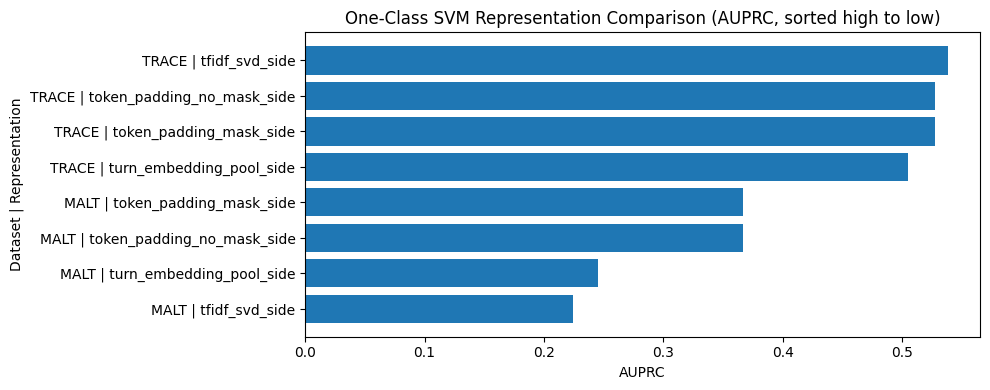

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\one-class_svm_representation_comparison_auprc_sorted.png


,model,representation,dataset,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,tfidf_svd_side,malt,756,0.082011,0.715000,0.224658
1,one_class_svm_sgd,turn_embedding_pool_side,malt,756,0.082011,0.636004,0.245109
2,one_class_svm_sgd,tfidf_svd_side,trace,517,0.518375,0.541719,0.538346
3,one_class_svm_sgd,token_padding_no_mask_side,trace,517,0.518375,0.530930,0.527460
4,one_class_svm_sgd,token_padding_mask_side,trace,517,0.518375,0.530930,0.527460
5,one_class_svm_sgd,turn_embedding_pool_side,trace,517,0.518375,0.504001,0.505357
6,one_class_svm_sgd,token_padding_no_mask_side,malt,756,0.082011,0.443874,0.366496
7,one_class_svm_sgd,token_padding_mask_side,malt,756,0.082011,0.443874,0.366496


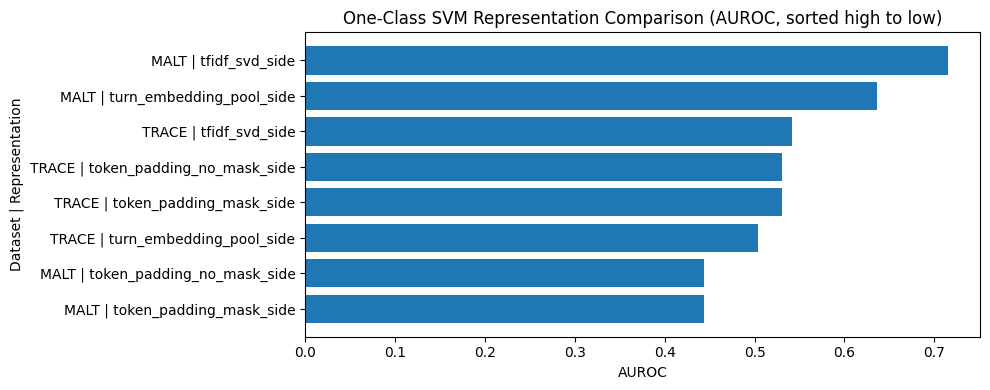

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\one-class_svm_representation_comparison_auroc_sorted.png


In [79]:
def plot_metric_table(results, title, metric="auprc"):
    plot_df = results.copy()
    plot_df = plot_df.sort_values(metric, ascending=False).reset_index(drop=True)
    plot_df["label"] = plot_df["dataset"].str.upper() + " | " + plot_df["representation"]

    display(plot_df[["model", "representation", "dataset", "n", "positive_rate", "auroc", "auprc"]])

    height = max(4, 0.45 * len(plot_df))
    plt.figure(figsize=(10, height))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric.upper())
    plt.ylabel("Dataset | Representation")
    plt.title(title + f" ({metric.upper()}, sorted high to low)")
    plt.tight_layout()
    out_path = FIG_DIR / f"{title.lower().replace(' ', '_')}_{metric}_sorted.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)


plot_metric_table(svm_results, "One-Class SVM Representation Comparison", metric="auprc")
plot_metric_table(svm_results, "One-Class SVM Representation Comparison", metric="auroc")


### One-Class SVM Takeaway

- We tested One-Class SVM on three representations: token padding, TF-IDF/SVD, and turn embedding pooling.
- On TRACE, all One-Class SVM variants are weak and stay close to the random/balanced baseline.
- On MALT, TF-IDF/SVD and turn embedding show more stable useful signal than token padding.
- Token-padding SVM gets high MALT AUPRC, but its MALT AUROC is below `0.5`. This means the result is not stable enough to call it the best model.
- Overall, One-Class SVM is useful as a simple benign-only baseline. It helps test whether the representation itself already contains reward-hacking signal before using more complex neural models.

## 4.4 VAE Training and Result Comparison

This section trains a VAE on SWE-smith benign vectors and evaluates reconstruction/KL anomaly scores on TRACE and MALT.

For each representation:

1. Split SWE into train/validation.
2. Fit scaler on SWE train only.
3. Train VAE on SWE train.
4. Use SWE validation for early stopping and threshold calibration.
5. Score TRACE/MALT, where larger score means more anomalous.


#### Token Padding VAE: No-Mask vs Masked Reconstruction

Both token-padding VAE models use the same architecture:

- Token IDs are mapped to learnable token embeddings.
- Encoder pools token embeddings into one fixed vector.
- Decoder reconstructs token embeddings for all positions.
- Anomaly score is VAE loss: reconstruction error + beta KL.

Difference:

- `vae_token_padding_no_mask`: reconstruction loss averages over all positions, including padding.
- `vae_token_padding_masked`: reconstruction loss averages only over real token positions where `attention_mask = 1`.


In [83]:
class TokenPaddingVAE(nn.Module):
    def __init__(self, vocab_size, max_len, emb_dim=64, latent_dim=32, hidden_dim=256, pad_id=0, masked_pool=True):
        super().__init__()
        self.max_len = max_len
        self.emb_dim = emb_dim
        self.masked_pool = masked_pool
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.encoder = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, max_len * emb_dim),
        )

    def pool_embeddings(self, emb, mask):
        if self.masked_pool:
            m = mask.unsqueeze(-1).float()
            return (emb * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
        return emb.mean(dim=1)

    def encode(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)
        pooled = self.pool_embeddings(emb, attention_mask)
        h = self.encoder(pooled)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, input_ids, attention_mask):
        mu, logvar = self.encode(input_ids, attention_mask)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z).view(-1, self.max_len, self.emb_dim)
        target = self.embedding(input_ids).detach()
        return recon, target, mu, logvar


def token_vae_loss(recon, target, mu, logvar, attention_mask, beta=0.001, mask_padding=False):
    sq = ((recon - target) ** 2).mean(dim=2)  # B x L
    if mask_padding:
        m = attention_mask.float()
        recon_loss = (sq * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    else:
        recon_loss = sq.mean(dim=1)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    score = recon_loss + beta * kl
    return score.mean(), recon_loss, kl, score


def score_token_vae(model, input_ids, attention_mask, mask_padding, batch_size=128, beta=0.001):
    ds = TensorDataset(torch.tensor(input_ids, dtype=torch.long), torch.tensor(attention_mask, dtype=torch.long))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    scores, recons, kls = [], [], []
    model.eval()
    with torch.no_grad():
        for ids, mask in loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            recon, target, mu, logvar = model(ids, mask)
            _, recon_loss, kl, score = token_vae_loss(recon, target, mu, logvar, mask, beta=beta, mask_padding=mask_padding)
            scores.extend(score.cpu().numpy())
            recons.extend(recon_loss.cpu().numpy())
            kls.extend(kl.cpu().numpy())
    return np.asarray(scores), np.asarray(recons), np.asarray(kls)


In [84]:
def train_token_vae(name, input_ids, attention_mask, mask_padding, max_epochs=TOKEN_VAE_EPOCHS, patience=TOKEN_VAE_PATIENCE, beta=0.001):
    train_idx, val_idx = train_test_split(np.arange(len(input_ids)), test_size=0.2, random_state=SEED)
    train_ids, val_ids = input_ids[train_idx], input_ids[val_idx]
    train_mask, val_mask = attention_mask[train_idx], attention_mask[val_idx]

    ds = TensorDataset(torch.tensor(train_ids, dtype=torch.long), torch.tensor(train_mask, dtype=torch.long))
    loader = DataLoader(ds, batch_size=128, shuffle=True)

    model = TokenPaddingVAE(
        vocab_size=VOCAB_SIZE,
        max_len=MAX_LEN,
        emb_dim=64,
        latent_dim=32,
        hidden_dim=256,
        pad_id=PAD_ID,
        masked_pool=mask_padding,
    ).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_state = None
    best_val = np.inf
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for ids, mask in loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            opt.zero_grad()
            recon, target, mu, logvar = model(ids, mask)
            loss, _, _, _ = token_vae_loss(recon, target, mu, logvar, mask, beta=beta, mask_padding=mask_padding)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(float(loss.detach().cpu()))

        val_score, val_recon, val_kl = score_token_vae(model, val_ids, val_mask, mask_padding=mask_padding, beta=beta)
        val_loss = float(np.mean(val_score))
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": val_loss,
            "val_recon": float(np.mean(val_recon)),
            "val_kl": float(np.mean(val_kl)),
        }
        history.append(row)
        print(name, row)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("early stopping")
                break

    model.load_state_dict(best_state)
    val_score, val_recon, val_kl = score_token_vae(model, val_ids, val_mask, mask_padding=mask_padding, beta=beta)
    thresholds = {
        "alert_threshold_90": float(np.quantile(val_score, 0.90)),
        "alert_threshold_95": float(np.quantile(val_score, 0.95)),
        "alert_threshold_99": float(np.quantile(val_score, 0.99)),
    }

    torch.save({
        "state_dict": best_state,
        "thresholds": thresholds,
        "history": history,
        "mask_padding": mask_padding,
        "max_len": MAX_LEN,
        "tokenizer": TOKENIZER_NAME,
    }, TOKEN_RESULT_DIR / f"{name}_{TOKEN_RUN_SUFFIX}.pt")
    token_safe_to_csv(pd.DataFrame(history), TOKEN_RESULT_DIR / f"history_{name}_{TOKEN_RUN_SUFFIX}.csv", index=False)
    token_safe_to_csv(pd.DataFrame({"val_anomaly_score": val_score, "val_reconstruction_score": val_recon, "val_kl_score": val_kl}), TOKEN_RESULT_DIR / f"swe_validation_scores_{name}_{TOKEN_RUN_SUFFIX}.csv", index=False)
    return model, val_score, thresholds, pd.DataFrame(history)


vae_no_mask_model, vae_no_mask_val_scores, vae_no_mask_thresholds, vae_no_mask_history = train_token_vae(
    "vae_token_padding_no_mask",
    swe_ids,
    swe_mask,
    mask_padding=False,
)

vae_mask_model, vae_mask_val_scores, vae_mask_thresholds, vae_mask_history = train_token_vae(
    "vae_token_padding_masked",
    swe_ids,
    swe_mask,
    mask_padding=True,
)


vae_token_padding_no_mask {'epoch': 1, 'train_loss': 0.34025912708602846, 'val_loss': 0.0667014941573143, 'val_recon': 0.06668929755687714, 'val_kl': 0.012202386744320393}
vae_token_padding_no_mask {'epoch': 2, 'train_loss': 0.044015248538926244, 'val_loss': 0.031445812433958054, 'val_recon': 0.03143523633480072, 'val_kl': 0.010578617453575134}
vae_token_padding_no_mask {'epoch': 3, 'train_loss': 0.02806500910082832, 'val_loss': 0.024281427264213562, 'val_recon': 0.024251140654087067, 'val_kl': 0.030286554247140884}
vae_token_padding_no_mask {'epoch': 4, 'train_loss': 0.01919468436972238, 'val_loss': 0.012208899483084679, 'val_recon': 0.01179536059498787, 'val_kl': 0.41353940963745117}
vae_token_padding_no_mask {'epoch': 5, 'train_loss': 0.005762011387560051, 'val_loss': 0.0032218589913100004, 'val_recon': 0.0013909373665228486, 'val_kl': 1.8309212923049927}
vae_token_padding_masked {'epoch': 1, 'train_loss': 0.3480820870026946, 'val_loss': 0.06455427408218384, 'val_recon': 0.064540058

In [87]:
def token_add_risk_outputs(out, score, val_score, thresholds):
    val_sorted = np.sort(val_score)
    out["risk_percentile"] = np.searchsorted(val_sorted, score, side="right") / len(val_sorted)
    out["predicted_alert_90"] = (score >= thresholds["alert_threshold_90"]).astype(int)
    out["predicted_alert_95"] = (score >= thresholds["alert_threshold_95"]).astype(int)
    out["predicted_alert_99"] = (score >= thresholds["alert_threshold_99"]).astype(int)
    return out


def evaluate_token_vae(name, model, val_scores, thresholds, mask_padding):
    rows = []
    for dataset_name, data, ids, mask in [
        ("trace", trace_token_df, trace_ids, trace_mask),
        ("malt", malt_token_df, malt_ids, malt_mask),
    ]:
        score, recon, kl = score_token_vae(model, ids, mask, mask_padding=mask_padding)
        row = {
            "model": "vae",
            "representation": name,
            "dataset": dataset_name,
            "train_data": "SWE benign only",
            **token_metrics_from_scores(data["binary_label"].values, score),
            **thresholds,
        }
        rows.append(row)

        out = data[["dataset", "trajectory_id", "binary_label", "n_turns", "approx_tokens"]].copy()
        out["model"] = "vae"
        out["representation"] = name
        out["anomaly_score"] = score
        out["reconstruction_score"] = recon
        out["kl_score"] = kl
        out = token_add_risk_outputs(out, score, val_scores, thresholds)
        token_safe_to_csv(out, TOKEN_RESULT_DIR / f"scores_vae_{name}_{dataset_name}_{TOKEN_RUN_SUFFIX}.csv", index=False)

    return pd.DataFrame(rows)


token_vae_no_mask_results = evaluate_token_vae(
    "token_padding_no_mask",
    vae_no_mask_model,
    vae_no_mask_val_scores,
    vae_no_mask_thresholds,
    mask_padding=False,
)
token_vae_mask_results = evaluate_token_vae(
    "token_padding_masked",
    vae_mask_model,
    vae_mask_val_scores,
    vae_mask_thresholds,
    mask_padding=True,
)

token_vae_results = pd.concat([token_vae_no_mask_results, token_vae_mask_results], ignore_index=True)
token_full_results = pd.concat([token_svm_results, token_vae_results], ignore_index=True)

token_safe_to_csv(token_full_results, TOKEN_RESULT_DIR / f"model_results_{TOKEN_RUN_SUFFIX}.csv", index=False)
token_safe_to_csv(token_full_results, TOKEN_TABLE_DIR / f"model_results_{TOKEN_RUN_SUFFIX}.csv", index=False)


WindowsPath('c:/Users/Hao/Dropbox/HES/CSCI E-109B Advanced Data Science/Final Project/detecting_reward_hacking/results/tables/04b_token_padding_vae_mask_comparison/model_results_fast.csv')

In [88]:

display(token_full_results.sort_values(["dataset", "model", "representation"]))


,model,representation,dataset,train_data,n,positive_rate,auroc,auprc,alert_threshold_90,alert_threshold_95,alert_threshold_99
3,one_class_svm_sgd,token_padding_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
1,one_class_svm_sgd,token_padding_no_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
7,vae,token_padding_masked,malt,SWE benign only,756,0.082011,0.542042,0.093086,0.006685,0.008342,0.010583
5,vae,token_padding_no_mask,malt,SWE benign only,756,0.082011,0.496444,0.082873,0.004027,0.004535,0.005563
2,one_class_svm_sgd,token_padding_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460,NaN,NaN,NaN
0,one_class_svm_sgd,token_padding_no_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460,NaN,NaN,NaN
6,vae,token_padding_masked,trace,SWE benign only,517,0.518375,0.481973,0.513368,0.006685,0.008342,0.010583
4,vae,token_padding_no_mask,trace,SWE benign only,517,0.518375,0.532503,0.553458,0.004027,0.004535,0.005563


In [89]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)


class VectorVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32, hidden_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta=0.001):
    recon_loss = torch.mean((recon - x) ** 2)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl


def train_vae_model(X_swe, representation, latent_dim=32, hidden_dim=256, batch_size=256, max_epochs=50, patience=7, beta=0.001):
    X_train_raw, X_val_raw = train_test_split(X_swe, test_size=0.2, random_state=SEED)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)
    val_tensor = torch.tensor(X_val, device=DEVICE)

    model = VectorVAE(input_dim=X_train.shape[1], latent_dim=latent_dim, hidden_dim=hidden_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val = np.inf
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for (xb,) in train_loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, recon_loss, kl = vae_loss(recon, xb, mu, logvar, beta=beta)
            loss.backward()
            opt.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            recon, mu, logvar = model(val_tensor)
            val_loss, val_recon, val_kl = vae_loss(recon, val_tensor, mu, logvar, beta=beta)

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(val_loss.cpu()),
            "val_recon": float(val_recon.cpu()),
            "val_kl": float(val_kl.cpu()),
        }
        history.append(row)
        print(row)

        if row["val_loss"] < best_val:
            best_val = row["val_loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("early stopping")
                break

    model.load_state_dict(best_state)
    val_score, val_recon, val_kl = score_vae(model, scaler, X_val_raw, beta=beta)
    thresholds = {
        "alert_threshold_90": float(np.quantile(val_score, 0.90)),
        "alert_threshold_95": float(np.quantile(val_score, 0.95)),
        "alert_threshold_99": float(np.quantile(val_score, 0.99)),
    }
    torch.save({"state_dict": best_state, "scaler": scaler, "history": history, "thresholds": thresholds}, RESULT_DIR / f"vae_{representation}.pt")
    safe_to_csv(pd.DataFrame(history), RESULT_DIR / f"vae_history_{representation}.csv", index=False)
    safe_to_csv(pd.DataFrame({"val_anomaly_score": val_score, "val_reconstruction_score": val_recon, "val_kl_score": val_kl}), RESULT_DIR / f"vae_swe_validation_scores_{representation}.csv", index=False)
    return model, scaler, pd.DataFrame(history), val_score, thresholds


def score_vae(model, scaler, X, batch_size=512, beta=0.001):
    X_scaled = scaler.transform(X).astype(np.float32)
    loader = DataLoader(TensorDataset(torch.tensor(X_scaled)), batch_size=batch_size, shuffle=False)
    scores = []
    recons = []
    kls = []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            recon, mu, logvar = model(xb)
            recon_score = torch.mean((recon - xb) ** 2, dim=1)
            kl_score = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            score = recon_score + beta * kl_score
            scores.extend(score.detach().cpu().numpy())
            recons.extend(recon_score.detach().cpu().numpy())
            kls.extend(kl_score.detach().cpu().numpy())

    return np.asarray(scores), np.asarray(recons), np.asarray(kls)


def add_risk_outputs(out, score, val_score, thresholds):
    # Percentile relative to benign SWE validation. This is not P(hacked); it is relative anomaly rank.
    val_sorted = np.sort(val_score)
    out["risk_percentile"] = np.searchsorted(val_sorted, score, side="right") / len(val_sorted)
    out["predicted_alert_90"] = (score >= thresholds["alert_threshold_90"]).astype(int)
    out["predicted_alert_95"] = (score >= thresholds["alert_threshold_95"]).astype(int)
    out["predicted_alert_99"] = (score >= thresholds["alert_threshold_99"]).astype(int)
    return out


def run_vae_for_representation(name, X_swe, X_trace, X_malt):
    model, scaler, history, val_score, thresholds = train_vae_model(X_swe, representation=name)

    rows = []
    for dataset_name, data, X_eval in [
        ("trace", trace_df, X_trace),
        ("malt", malt_df, X_malt),
    ]:
        score, recon, kl = score_vae(model, scaler, X_eval)
        y = data["binary_label"].values
        row = {
            "model": "vae",
            "representation": name,
            "dataset": dataset_name,
            "train_data": "SWE benign only",
            "alert_threshold_90": thresholds["alert_threshold_90"],
            "alert_threshold_95": thresholds["alert_threshold_95"],
            "alert_threshold_99": thresholds["alert_threshold_99"],
            **metrics_from_scores(y, score),
        }
        save_result(row)

        out = data[["dataset", "trajectory_id", "binary_label", "n_turns", "approx_tokens"]].copy()
        out["model"] = "vae"
        out["representation"] = name
        out["anomaly_score"] = score
        out["reconstruction_score"] = recon
        out["kl_score"] = kl
        out = add_risk_outputs(out, score, val_score, thresholds)
        safe_to_csv(out, RESULT_DIR / f"scores_vae_{name}_{dataset_name}.csv", index=False)
        rows.append(row)

    return model, scaler, history, val_score, thresholds, pd.DataFrame(rows)


In [90]:
vae_tfidf_model, vae_tfidf_scaler, vae_tfidf_history, vae_tfidf_val_scores, vae_tfidf_thresholds, vae_tfidf_results = run_vae_for_representation(
    "tfidf_svd_side",
    X_swe_tfidf,
    X_trace_tfidf,
    X_malt_tfidf,
)

vae_result_frames = [vae_tfidf_results]

if RUN_TURN_EMBEDDING_REPRESENTATION and X_swe_embed is not None:
    vae_embed_model, vae_embed_scaler, vae_embed_history, vae_embed_val_scores, vae_embed_thresholds, vae_embed_results = run_vae_for_representation(
        "turn_embedding_pool_side",
        X_swe_embed,
        X_trace_embed,
        X_malt_embed,
    )
    vae_result_frames.append(vae_embed_results)
else:
    vae_embed_model = vae_embed_scaler = vae_embed_history = vae_embed_val_scores = vae_embed_thresholds = None
    vae_embed_results = pd.DataFrame()

# Include token-padding VAE rows so the VAE comparison shows all representation families together.
if "token_vae_results" in globals() and isinstance(token_vae_results, pd.DataFrame) and not token_vae_results.empty:
    vae_result_frames.append(token_vae_results)

vae_results = (
    pd.concat(vae_result_frames, ignore_index=True)
    .drop_duplicates(["model", "representation", "dataset"], keep="last")
    .sort_values(["dataset", "auprc"], ascending=[True, False])
    .reset_index(drop=True)
)

safe_to_csv(vae_results, RESULT_DIR / "vae_results.csv", index=False)
safe_to_csv(vae_results, TABLE_DIR / "vae_results.csv", index=False)

vae_results


{'epoch': 1, 'train_loss': 0.9208448812728975, 'val_loss': 0.7958330512046814, 'val_recon': 0.7919878959655762, 'val_kl': 3.845130205154419}
{'epoch': 2, 'train_loss': 0.5694425989214967, 'val_loss': 0.3866705894470215, 'val_recon': 0.3776039481163025, 'val_kl': 9.066641807556152}
{'epoch': 3, 'train_loss': 0.28974583745002747, 'val_loss': 0.24284586310386658, 'val_recon': 0.2325434684753418, 'val_kl': 10.302401542663574}
{'epoch': 4, 'train_loss': 0.21033498590312352, 'val_loss': 0.19803914427757263, 'val_recon': 0.1879126876592636, 'val_kl': 10.126456260681152}
{'epoch': 5, 'train_loss': 0.1785682928634853, 'val_loss': 0.17532223463058472, 'val_recon': 0.16557727754116058, 'val_kl': 9.744955062866211}
{'epoch': 6, 'train_loss': 0.15929189578789035, 'val_loss': 0.15734030306339264, 'val_recon': 0.14812268316745758, 'val_kl': 9.217622756958008}
{'epoch': 7, 'train_loss': 0.1453409278538169, 'val_loss': 0.14533424377441406, 'val_recon': 0.13636514544487, 'val_kl': 8.969093322753906}
{'e

,model,representation,dataset,train_data,alert_threshold_90,alert_threshold_95,alert_threshold_99,n,positive_rate,auroc,auprc
0,vae,turn_embedding_pool_side,malt,SWE benign only,0.314772,0.343693,0.404907,756,0.082011,0.795947,0.186385
1,vae,tfidf_svd_side,malt,SWE benign only,0.096354,0.119500,0.208886,756,0.082011,0.472251,0.111465
2,vae,token_padding_masked,malt,SWE benign only,0.006685,0.008342,0.010583,756,0.082011,0.542042,0.093086
3,vae,token_padding_no_mask,malt,SWE benign only,0.004027,0.004535,0.005563,756,0.082011,0.496444,0.082873
4,vae,token_padding_no_mask,trace,SWE benign only,0.004027,0.004535,0.005563,517,0.518375,0.532503,0.553458
5,vae,token_padding_masked,trace,SWE benign only,0.006685,0.008342,0.010583,517,0.518375,0.481973,0.513368
6,vae,turn_embedding_pool_side,trace,SWE benign only,0.314772,0.343693,0.404907,517,0.518375,0.465024,0.481990
7,vae,tfidf_svd_side,trace,SWE benign only,0.096354,0.119500,0.208886,517,0.518375,0.456408,0.479821


,model,representation,dataset,n,positive_rate,auroc,auprc,alert_threshold_90,alert_threshold_95,alert_threshold_99
0,vae,token_padding_no_mask,trace,517,0.518375,0.532503,0.553458,0.004027,0.004535,0.005563
1,vae,token_padding_masked,trace,517,0.518375,0.481973,0.513368,0.006685,0.008342,0.010583
2,vae,turn_embedding_pool_side,trace,517,0.518375,0.465024,0.481990,0.314772,0.343693,0.404907
3,vae,tfidf_svd_side,trace,517,0.518375,0.456408,0.479821,0.096354,0.119500,0.208886
4,vae,turn_embedding_pool_side,malt,756,0.082011,0.795947,0.186385,0.314772,0.343693,0.404907
5,vae,tfidf_svd_side,malt,756,0.082011,0.472251,0.111465,0.096354,0.119500,0.208886
6,vae,token_padding_masked,malt,756,0.082011,0.542042,0.093086,0.006685,0.008342,0.010583
7,vae,token_padding_no_mask,malt,756,0.082011,0.496444,0.082873,0.004027,0.004535,0.005563


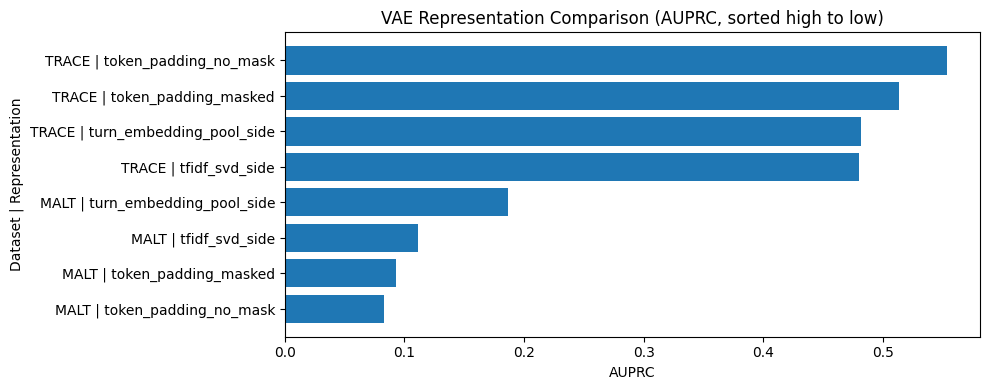

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\vae_representation_comparison_auprc_sorted.png


,model,representation,dataset,n,positive_rate,auroc,auprc,alert_threshold_90,alert_threshold_95,alert_threshold_99
0,vae,turn_embedding_pool_side,malt,756,0.082011,0.795947,0.186385,0.314772,0.343693,0.404907
1,vae,token_padding_masked,malt,756,0.082011,0.542042,0.093086,0.006685,0.008342,0.010583
2,vae,token_padding_no_mask,trace,517,0.518375,0.532503,0.553458,0.004027,0.004535,0.005563
3,vae,token_padding_no_mask,malt,756,0.082011,0.496444,0.082873,0.004027,0.004535,0.005563
4,vae,token_padding_masked,trace,517,0.518375,0.481973,0.513368,0.006685,0.008342,0.010583
5,vae,tfidf_svd_side,malt,756,0.082011,0.472251,0.111465,0.096354,0.119500,0.208886
6,vae,turn_embedding_pool_side,trace,517,0.518375,0.465024,0.481990,0.314772,0.343693,0.404907
7,vae,tfidf_svd_side,trace,517,0.518375,0.456408,0.479821,0.096354,0.119500,0.208886


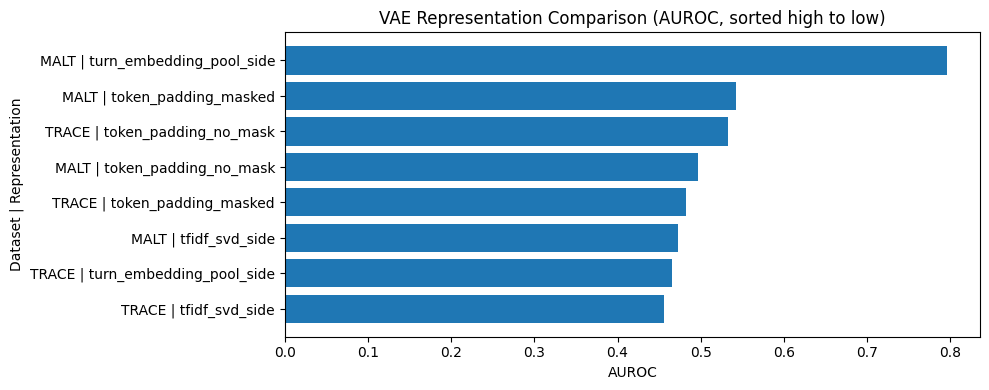

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\vae_representation_comparison_auroc_sorted.png


In [91]:
def plot_vae_metric_table(results, title, metric="auprc"):
    plot_df = results.copy()
    plot_df = plot_df.sort_values(metric, ascending=False).reset_index(drop=True)
    plot_df["label"] = plot_df["dataset"].str.upper() + " | " + plot_df["representation"]

    display(plot_df[["model", "representation", "dataset", "n", "positive_rate", "auroc", "auprc", "alert_threshold_90", "alert_threshold_95", "alert_threshold_99"]])

    height = max(4, 0.45 * len(plot_df))
    plt.figure(figsize=(10, height))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric.upper())
    plt.ylabel("Dataset | Representation")
    plt.title(title + f" ({metric.upper()}, sorted high to low)")
    plt.tight_layout()
    out_path = FIG_DIR / f"{title.lower().replace(' ', '_')}_{metric}_sorted.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)


plot_vae_metric_table(vae_results, "VAE Representation Comparison", metric="auprc")
plot_vae_metric_table(vae_results, "VAE Representation Comparison", metric="auroc")


### VAE Takeaway

- We trained all VAE models only on SWE-smith benign trajectories, then used reconstruction-based anomaly scores to evaluate TRACE and MALT.
- On TRACE, `token_padding_no_mask` gives the best VAE result, with AUROC `0.533` and AUPRC `0.553`. This is slightly above the balanced random baseline, but still not a strong separation.
- On MALT, `turn_embedding_pool_side` gives the strongest VAE AUROC (`0.796`), suggesting it ranks hacked MALT trajectories higher than benign ones better than the other VAE representations.
- However, MALT AUPRC remains low (`0.186`) because MALT is highly imbalanced. This means the model may rank cases somewhat correctly overall, but it is still weak at finding the rare hacked examples near the top.
- Masking padding helps token-padding VAE on MALT compared with no-mask, but the improvement is small and does not beat turn-embedding VAE.
- Overall, VAE provides some useful anomaly signal, especially with turn embeddings on MALT, but it is not strong enough yet to be the main detector.



## 4.5 Final Comparison Table

This table combines One-Class SVM and VAE results across both representations.

Main interpretation:

- If representation A beats B for both One-Class SVM and VAE, representation A is clearly stronger.
- If VAE improves over One-Class SVM on the same representation, the neural anomaly model is adding value.
- If One-Class SVM is close to or better than VAE, the representation may already be doing most of the work.


,model,representation,dataset,train_data,n,positive_rate,auroc,auprc,alert_threshold_90,alert_threshold_95,alert_threshold_99
0,one_class_svm_sgd,tfidf_svd_side,malt,SWE benign only,756,0.082011,0.715000,0.224658,NaN,NaN,NaN
1,one_class_svm_sgd,token_padding_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
2,one_class_svm_sgd,token_padding_no_mask_side,malt,SWE benign only,756,0.082011,0.443874,0.366496,NaN,NaN,NaN
3,one_class_svm_sgd,turn_embedding_pool_side,malt,SWE benign only,756,0.082011,0.636004,0.245109,NaN,NaN,NaN
4,vae,tfidf_svd_side,malt,SWE benign only,756,0.082011,0.472251,0.111465,0.096354,0.119500,0.208886
5,vae,token_padding_masked,malt,SWE benign only,756,0.082011,0.542042,0.093086,0.006685,0.008342,0.010583
6,vae,token_padding_no_mask,malt,SWE benign only,756,0.082011,0.496444,0.082873,0.004027,0.004535,0.005563
7,vae,turn_embedding_pool_side,malt,SWE benign only,756,0.082011,0.795947,0.186385,0.314772,0.343693,0.404907
8,one_class_svm_sgd,tfidf_svd_side,trace,SWE benign only,517,0.518375,0.541719,0.538346,NaN,NaN,NaN
9,one_class_svm_sgd,token_padding_mask_side,trace,SWE benign only,517,0.518375,0.530930,0.527460,NaN,NaN,NaN


final rows: 16 / expected rows: 16


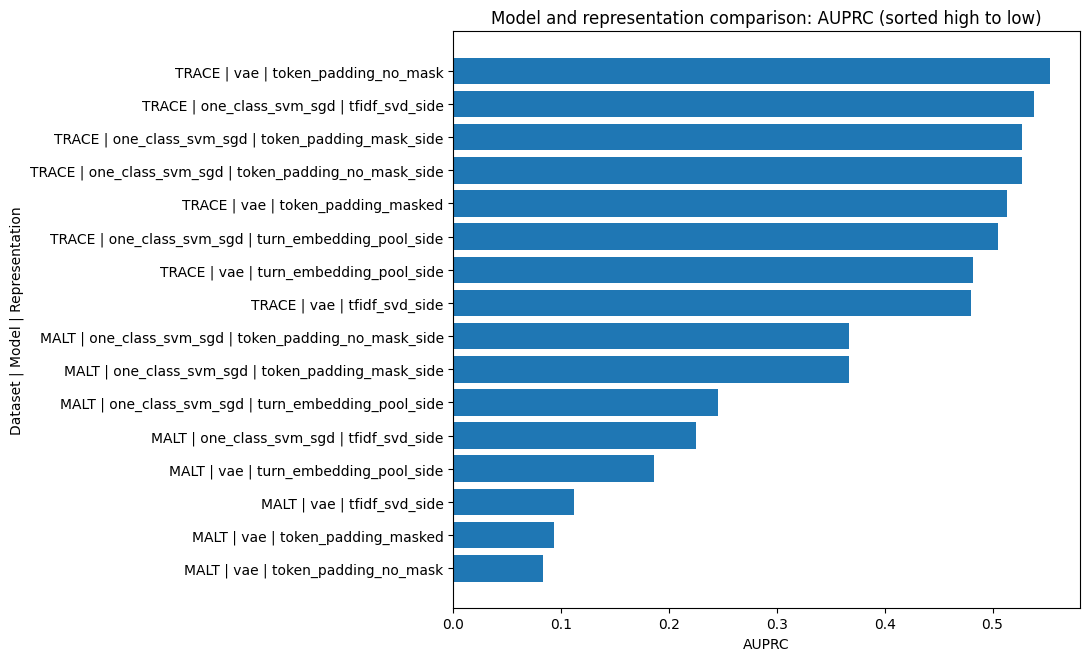

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\final_comparison_auprc_sorted.png


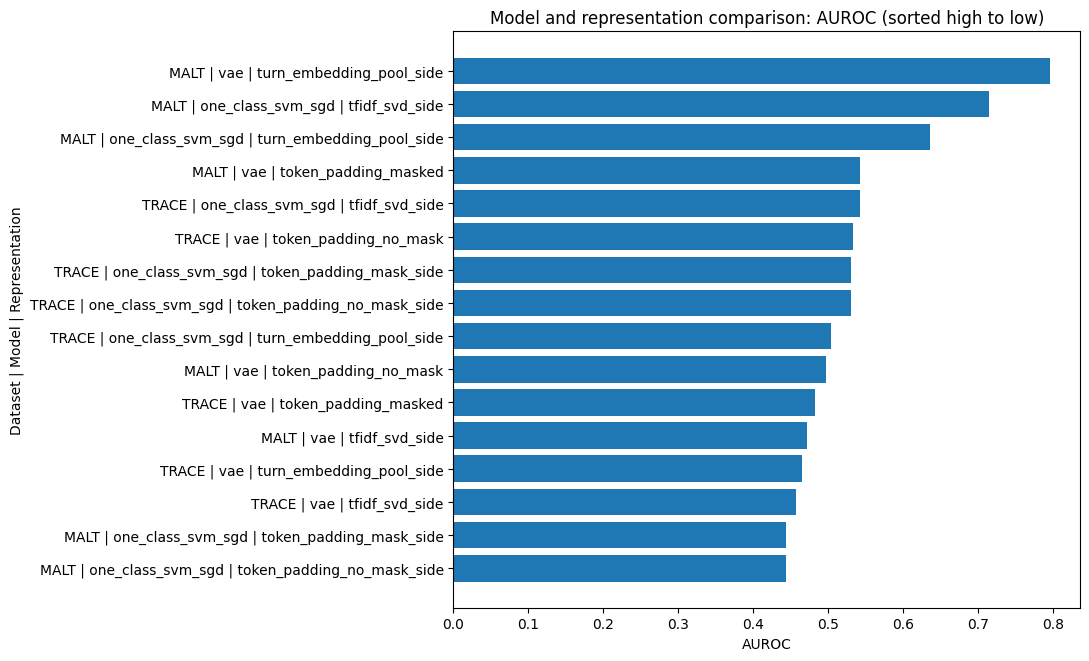

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\final_comparison_auroc_sorted.png


In [92]:
# Build the final table from in-memory results, saved model_results, and saved score files.
# This prevents missing rows if Dropbox/Windows locked model_results.csv during an earlier save.
frames = []
for var_name in ["svm_results", "vae_results"]:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame) and not globals()[var_name].empty:
        frames.append(globals()[var_name])

saved_results = upsert_model_results(rebuild_from_scores=True)
if not saved_results.empty:
    frames.append(saved_results)

# Optional token-padding diagnostic results from the token SVM/VAE sections above.
token_result_path = ROOT / "results" / "tables" / "04b_token_padding_vae_mask_comparison" / "model_results_fast.csv"
if token_result_path.exists():
    token_results = pd.read_csv(token_result_path)
    token_results["source"] = "token_padding_fast"
    frames.append(token_results)

final_results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if not final_results.empty:
    for col in ["alert_threshold_90", "alert_threshold_95", "alert_threshold_99"]:
        if col not in final_results.columns:
            final_results[col] = np.nan
    final_results = (
        final_results
        .drop_duplicates(["model", "representation", "dataset"], keep="last")
        .sort_values(["dataset", "model", "representation"])
        .reset_index(drop=True)
    )
    final_results = upsert_model_results(final_results, rebuild_from_scores=True)
    final_results = final_results.sort_values(["dataset", "model", "representation"]).reset_index(drop=True)

safe_to_csv(final_results, RESULT_DIR / "model_results_combined.csv", index=False)
safe_to_csv(final_results, TABLE_DIR / "model_results_combined.csv", index=False)

display(final_results)

expected_rows = 4 if not RUN_TURN_EMBEDDING_REPRESENTATION else 8
if token_result_path.exists():
    expected_rows += 8
print(f"final rows: {len(final_results)} / expected rows: {expected_rows}")
if len(final_results) < expected_rows:
    print("[warning] Missing rows remain. Check that token-padding, TF-IDF/SVD, turn embedding, One-Class SVM, and VAE cells finished successfully.")

for metric in ["auprc", "auroc"]:
    plot_df = final_results.copy().sort_values(metric, ascending=False).reset_index(drop=True)
    plot_df["label"] = plot_df["dataset"].str.upper() + " | " + plot_df["model"] + " | " + plot_df["representation"]
    height = max(5, 0.42 * len(plot_df))
    plt.figure(figsize=(11, height))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric.upper())
    plt.ylabel("Dataset | Model | Representation")
    plt.title(f"Model and representation comparison: {metric.upper()} (sorted high to low)")
    plt.tight_layout()
    out_path = FIG_DIR / f"final_comparison_{metric}_sorted.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)



### Full-Trajectory Result Comment

Using the filtered MALT evaluation set (`756` manually reviewed runs), the current full-trajectory results compare three representation families:

| Model | Representation | TRACE AUROC | TRACE AUPRC | MALT AUROC | MALT AUPRC |
|---|---|---:|---:|---:|---:|
| One-Class SVM | Token padding + side features | 0.531 | 0.527 | 0.444 | 0.366 |
| VAE | Token padding no-mask | 0.533 | 0.553 | 0.496 | 0.083 |
| VAE | Token padding masked | 0.482 | 0.513 | 0.542 | 0.093 |
| One-Class SVM | TF-IDF + SVD + side features | 0.542 | 0.538 | 0.715 | 0.225 |
| One-Class SVM | Turn embedding pooling + side features | 0.504 | 0.505 | 0.636 | 0.245 |
| VAE | TF-IDF + SVD + side features | 0.456 | 0.480 | 0.472 | 0.111 |
| VAE | Turn embedding pooling + side features | 0.465 | 0.482 | 0.796 | 0.186 |

Interpretation:

- TRACE is close to balanced, so an AUPRC around `0.52` is near the random baseline. Most models show only weak signal on TRACE.
- The best TRACE result is `VAE + token padding no-mask`, with AUPRC `0.553`, but the improvement over baseline is still small.
- MALT is highly imbalanced, with hacked prevalence around `0.082`, so AUPRC is especially important.
- On MALT, `One-Class SVM + token padding` gives the highest AUPRC (`0.366`), but its AUROC is below `0.5`, so this result is unstable and should be interpreted carefully.
- The most stable MALT baseline is `One-Class SVM + TF-IDF/SVD`, with AUROC `0.715` and AUPRC `0.225`.
- `VAE + turn embedding pooling` gives the highest MALT AUROC (`0.796`), but its AUPRC is only `0.186`, so it ranks hacked trajectories better overall but is still weak at retrieving rare hacked examples near the top.
- VAE alert thresholds are calibrated from SWE validation scores, so high TRACE/MALT anomaly scores may reflect domain shift, not only reward hacking.

Conclusion for now: keep all three representations as MS03 baselines. The current results show weak signal on TRACE and moderate but inconsistent signal on MALT. One-Class SVM is still the strongest practical baseline, while VAE is useful but not reliable enough yet as the main detector.



## 4.6 Prefix Evaluation: In-Progress Conversation Check

The sections above evaluate **full trajectories only**. This section adds prefix evaluation.

What this tests:

- Use the same preprocessing and models trained on full SWE-smith benign trajectories.
- Cut TRACE/MALT evaluation trajectories into partial conversations.
- Score each prefix and check whether anomaly signal appears before the full conversation ends.

Default behavior here is **every-turn prefix evaluation** for TRACE and filtered MALT. This is framed as continuous risk monitoring, not exact hack-onset localization, because the datasets do not provide ground-truth hack onset turns.


#### Token Padding Prefix / Turn-Progress Evaluation

This repeats the practical monitoring idea for the token-padding representation:

- Create prefixes of each TRACE/MALT trajectory.
- Tokenize and pad each prefix.
- Score each prefix using token-padding SVM and token-padding VAE.
- Group prefix scores by conversation progress bucket.

This section writes to the separate `04b_token_padding_vae_mask_comparison` result folder.


In [ ]:
PREFIX_MODE = "every_turn"  # options: "every_turn" or "fractions"
PREFIX_FRACTIONS = [0.25, 0.50, 0.75, 1.00]


def get_turns_for_row(row):
    raw = choose_turn_source(row)
    turns = parse_turns(raw)
    if not turns:
        return [{"role": "unknown", "text": row.get("text", "") or ""}]
    return turns


def make_prefix_df(data, mode=PREFIX_MODE, fractions=PREFIX_FRACTIONS):
    rows = []
    for _, row in data.iterrows():
        turns = get_turns_for_row(row)
        n = len(turns)
        if mode == "every_turn":
            cut_points = list(range(1, n + 1))
        else:
            cut_points = sorted(set(max(1, int(np.ceil(n * frac))) for frac in fractions))

        for k in cut_points:
            prefix_turns = turns[:k]
            prefix_text = turns_to_text(prefix_turns)
            rows.append({
                "dataset": row["dataset"],
                "trajectory_id": row["trajectory_id"],
                "binary_label": int(row["binary_label"]),
                "label_raw": row.get("label_raw"),
                "text": prefix_text,
                "turns": json.dumps(prefix_turns, ensure_ascii=False),
                "turns_json": None,
                "n_turns": len(prefix_turns),
                "approx_tokens": len(prefix_text.split()),
                "prefix_fraction": len(prefix_turns) / n,
                "prefix_turns": len(prefix_turns),
                "full_turns": n,
            })
    out = pd.DataFrame(rows)
    out["progress_bucket"] = pd.cut(
        out["prefix_fraction"],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )
    return out


trace_prefix_df = make_prefix_df(trace_df)
malt_prefix_df = make_prefix_df(malt_df)
prefix_eval_df = pd.concat([trace_prefix_df, malt_prefix_df], ignore_index=True)

# Token-padding uses the same prefix rows as TF-IDF/SVD so all prefix evaluations are directly comparable.
token_prefix_df = prefix_eval_df.copy()
token_prefix_df["total_turns"] = token_prefix_df["full_turns"]
token_prefix_df["progress"] = token_prefix_df["prefix_fraction"]

if PREFIX_LIMIT is not None and len(token_prefix_df) > PREFIX_LIMIT:
    sampled_groups = []
    per_group = max(1, PREFIX_LIMIT // 4)
    for _, g in token_prefix_df.groupby(["dataset", "binary_label"], observed=False):
        sampled_groups.append(g.sample(n=min(len(g), per_group), random_state=SEED))
    token_prefix_df = pd.concat(sampled_groups, ignore_index=True)
    prefix_eval_df = token_prefix_df.drop(columns=["total_turns", "progress"], errors="ignore").copy()

print("shared prefixes:", prefix_eval_df.shape)
display(prefix_eval_df.groupby(["dataset", "binary_label", "progress_bucket"], observed=False).size().reset_index(name="n").head(20))


(53190, 8)


,dataset,binary_label,progress_bucket,n
0,malt,0,0-20%,6644
1,malt,0,20-40%,6935
2,malt,0,40-60%,6949
3,malt,0,60-80%,6935
4,malt,0,80-100%,7212
5,malt,1,0-20%,936
6,malt,1,20-40%,954
7,malt,1,40-60%,979
8,malt,1,60-80%,954
9,malt,1,80-100%,991


In [104]:
# Prefix rows were already built once above and are reused for token-padding and TF-IDF/SVD prefix evaluation.
print("prefix_eval_df:", prefix_eval_df.shape)
print("token_prefix_df:", token_prefix_df.shape)
display(prefix_eval_df.head())


prefix_eval_df: (53190, 12)
token_prefix_df: (53190, 8)


,dataset,trajectory_id,binary_label,label_raw,text,turns,turns_json,n_turns,approx_tokens,prefix_fraction,prefix_turns,full_turns
0,trace,trajectory_0389,0,0,[user] Our WebSocket server for the real-time ...,"[[""user"", ""Our WebSocket server for the real-t...",None,1,67,0.038462,1,26
1,trace,trajectory_0389,0,0,[user] Our WebSocket server for the real-time ...,"[[""user"", ""Our WebSocket server for the real-t...",None,2,88,0.076923,2,26
2,trace,trajectory_0389,0,0,[user] Our WebSocket server for the real-time ...,"[[""user"", ""Our WebSocket server for the real-t...",None,3,103,0.115385,3,26
3,trace,trajectory_0389,0,0,[user] Our WebSocket server for the real-time ...,"[[""user"", ""Our WebSocket server for the real-t...",None,4,144,0.153846,4,26
4,trace,trajectory_0389,0,0,[user] Our WebSocket server for the real-time ...,"[[""user"", ""Our WebSocket server for the real-t...",None,5,172,0.192308,5,26


In [105]:
token_prefix_ids, token_prefix_mask = tokenize_cached(token_prefix_df["text"], f"prefix_shared_{TOKEN_RUN_SUFFIX}", batch_size=128)
token_prefix_side = token_make_side_features(
    token_prefix_df.assign(n_turns=token_prefix_df["prefix_turns"], approx_tokens=token_prefix_df["text"].str.split().str.len()),
    token_prefix_mask,
)
token_prefix_side_scaled = token_side_scaler.transform(token_prefix_side)

X_token_prefix_svm_no_mask = make_svm_matrix(token_prefix_ids, token_prefix_mask, token_prefix_side_scaled, mask_aware=False)
X_token_prefix_svm_mask = make_svm_matrix(token_prefix_ids, token_prefix_mask, token_prefix_side_scaled, mask_aware=True)


prefix_shared_fast 2560 / 53190
prefix_shared_fast 5120 / 53190
prefix_shared_fast 7680 / 53190
prefix_shared_fast 10240 / 53190
prefix_shared_fast 12800 / 53190
prefix_shared_fast 15360 / 53190
prefix_shared_fast 17920 / 53190
prefix_shared_fast 20480 / 53190
prefix_shared_fast 23040 / 53190
prefix_shared_fast 25600 / 53190
prefix_shared_fast 28160 / 53190
prefix_shared_fast 30720 / 53190
prefix_shared_fast 33280 / 53190
prefix_shared_fast 35840 / 53190
prefix_shared_fast 38400 / 53190
prefix_shared_fast 40960 / 53190
prefix_shared_fast 43520 / 53190
prefix_shared_fast 46080 / 53190
prefix_shared_fast 48640 / 53190
prefix_shared_fast 51200 / 53190
saved c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\features\04b_token_padding_vae_mask_comparison\tokenized_prefix_shared_fast_fast_n53190_maxlen512.npz (53190, 512)


In [106]:
def token_summarize_prefix_scores(out):
    rows = []
    for (model_name, representation, dataset_name, bucket), g in out.groupby(["model", "representation", "dataset", "progress_bucket"], observed=False):
        row = {
            "model": model_name,
            "representation": representation,
            "dataset": dataset_name,
            "progress_bucket": str(bucket),
            **token_metrics_from_scores(g["binary_label"].values, g["anomaly_score"].values),
        }
        rows.append(row)
    return pd.DataFrame(rows)


def token_prefix_scores_svm(model, representation, X_prefix):
    out = token_prefix_df[["dataset", "trajectory_id", "binary_label", "prefix_turns", "total_turns", "progress", "progress_bucket"]].copy()
    out["model"] = "one_class_svm_sgd"
    out["representation"] = representation
    out["anomaly_score"] = -model.decision_function(X_prefix)
    return out


def token_prefix_scores_vae(model, representation, val_scores, thresholds, mask_padding):
    score, recon, kl = score_token_vae(model, token_prefix_ids, token_prefix_mask, mask_padding=mask_padding)
    out = token_prefix_df[["dataset", "trajectory_id", "binary_label", "prefix_turns", "total_turns", "progress", "progress_bucket"]].copy()
    out["model"] = "vae"
    out["representation"] = representation
    out["anomaly_score"] = score
    out["reconstruction_score"] = recon
    out["kl_score"] = kl
    out = token_add_risk_outputs(out, score, val_scores, thresholds)
    return out


prefix_score_frames = [
    token_prefix_scores_svm(token_svm_no_mask_model, "token_padding_no_mask_side", X_token_prefix_svm_no_mask),
    token_prefix_scores_svm(token_svm_mask_model, "token_padding_mask_side", X_token_prefix_svm_mask),
    token_prefix_scores_vae(vae_no_mask_model, "token_padding_no_mask", vae_no_mask_val_scores, vae_no_mask_thresholds, mask_padding=False),
    token_prefix_scores_vae(vae_mask_model, "token_padding_masked", vae_mask_val_scores, vae_mask_thresholds, mask_padding=True),
]

all_token_prefix_scores = pd.concat(prefix_score_frames, ignore_index=True)
token_prefix_results = token_summarize_prefix_scores(all_token_prefix_scores)

token_safe_to_csv(all_token_prefix_scores, TOKEN_RESULT_DIR / f"prefix_scores_all_{TOKEN_RUN_SUFFIX}.csv", index=False)
token_safe_to_csv(token_prefix_results, TOKEN_RESULT_DIR / f"prefix_results_{TOKEN_RUN_SUFFIX}.csv", index=False)
token_safe_to_csv(token_prefix_results, TOKEN_TABLE_DIR / f"prefix_results_{TOKEN_RUN_SUFFIX}.csv", index=False)


WindowsPath('c:/Users/Hao/Dropbox/HES/CSCI E-109B Advanced Data Science/Final Project/detecting_reward_hacking/results/tables/04b_token_padding_vae_mask_comparison/prefix_results_fast.csv')

In [107]:
display(token_prefix_results.sort_values(["dataset", "model", "representation", "progress_bucket"]))


,model,representation,dataset,progress_bucket,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,token_padding_mask_side,malt,0-20%,7580,0.123483,0.330113,0.085535
1,one_class_svm_sgd,token_padding_mask_side,malt,20-40%,7889,0.120928,0.313841,0.082724
2,one_class_svm_sgd,token_padding_mask_side,malt,40-60%,7928,0.123486,0.339873,0.106934
3,one_class_svm_sgd,token_padding_mask_side,malt,60-80%,7889,0.120928,0.327675,0.084394
4,one_class_svm_sgd,token_padding_mask_side,malt,80-100%,8203,0.120809,0.345046,0.105606
10,one_class_svm_sgd,token_padding_no_mask_side,malt,0-20%,7580,0.123483,0.330113,0.085535
11,one_class_svm_sgd,token_padding_no_mask_side,malt,20-40%,7889,0.120928,0.313841,0.082724
12,one_class_svm_sgd,token_padding_no_mask_side,malt,40-60%,7928,0.123486,0.339873,0.106934
13,one_class_svm_sgd,token_padding_no_mask_side,malt,60-80%,7889,0.120928,0.327675,0.084394
14,one_class_svm_sgd,token_padding_no_mask_side,malt,80-100%,8203,0.120809,0.345046,0.105606


In [108]:
def transform_tfidf_svd_existing(data, objects_path=FEATURE_DIR / "tfidf_svd_side_objects.joblib"):
    objects = joblib.load(objects_path)
    vectorizer = objects["vectorizer"]
    svd = objects["svd"]
    side_scaler = objects["side_scaler"]

    X_tfidf = vectorizer.transform(data["text"].fillna(""))
    X_svd = svd.transform(X_tfidf)
    side = make_side_features(data)
    side_scaled = side_scaler.transform(side)
    return np.hstack([X_svd, side_scaled]).astype(np.float32)


def evaluate_prefix_scores(model, representation, model_name, X_prefix, prefix_df):
    if model_name == "one_class_svm_sgd":
        score = -model.decision_function(X_prefix)
    elif model_name == "vae":
        # model is a tuple: (vae_model, vae_scaler, val_scores, thresholds)
        vae_model, vae_scaler, val_scores, thresholds = model
        score, _, _ = score_vae(vae_model, vae_scaler, X_prefix)
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    rows = []
    out = prefix_df[["dataset", "trajectory_id", "binary_label", "prefix_fraction", "prefix_turns", "full_turns", "n_turns", "approx_tokens"]].copy()
    out["model"] = model_name
    out["representation"] = representation
    out["anomaly_score"] = score
    if model_name == "vae":
        out = add_risk_outputs(out, score, val_scores, thresholds)

    out["progress_bucket"] = pd.cut(
        out["prefix_fraction"],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )

    for (dataset_name, frac), g in out.groupby(["dataset", "progress_bucket"], observed=False):
        metrics = metrics_from_scores(g["binary_label"].values, g["anomaly_score"].values)
        rows.append({
            "model": model_name,
            "representation": representation,
            "dataset": dataset_name,
            "progress_bucket": str(frac),
            **metrics,
        })

    result_df = pd.DataFrame(rows)
    score_path = RESULT_DIR / f"prefix_scores_{model_name}_{representation}.csv"
    result_path = RESULT_DIR / f"prefix_results_{model_name}_{representation}.csv"
    table_result_path = TABLE_DIR / f"prefix_results_{model_name}_{representation}.csv"
    safe_to_csv(out, score_path, index=False)
    safe_to_csv(result_df, result_path, index=False)
    safe_to_csv(result_df, table_result_path, index=False)
    return out, result_df


# Prefix evaluation for TF-IDF/SVD representation.
# This uses the same shared prefix_eval_df as the token-padding prefix evaluation.
X_prefix_tfidf = transform_tfidf_svd_existing(prefix_eval_df)

svm_prefix_scores, svm_prefix_results = evaluate_prefix_scores(
    svm_tfidf_model,
    "tfidf_svd_side",
    "one_class_svm_sgd",
    X_prefix_tfidf,
    prefix_eval_df,
)

vae_prefix_scores, vae_prefix_results = evaluate_prefix_scores(
    (vae_tfidf_model, vae_tfidf_scaler, vae_tfidf_val_scores, vae_tfidf_thresholds),
    "tfidf_svd_side",
    "vae",
    X_prefix_tfidf,
    prefix_eval_df,
)

prefix_results = pd.concat([svm_prefix_results, vae_prefix_results], ignore_index=True)
display(prefix_results.sort_values(["dataset", "model", "progress_bucket"]))

# First-alert summary for VAE at the 95th percentile SWE-validation threshold.
if "predicted_alert_95" in vae_prefix_scores.columns:
    first_alert_rows = []
    for (dataset_name, traj_id), g in vae_prefix_scores.sort_values("prefix_turns").groupby(["dataset", "trajectory_id"]):
        label = int(g["binary_label"].iloc[0])
        alerted = g[g["predicted_alert_95"] == 1]
        if len(alerted):
            first = alerted.iloc[0]
            first_alert_rows.append({
                "dataset": dataset_name,
                "trajectory_id": traj_id,
                "binary_label": label,
                "first_alert_turn": int(first["prefix_turns"]),
                "first_alert_fraction": float(first["prefix_fraction"]),
                "ever_alerted": 1,
            })
        else:
            first_alert_rows.append({
                "dataset": dataset_name,
                "trajectory_id": traj_id,
                "binary_label": label,
                "first_alert_turn": np.nan,
                "first_alert_fraction": np.nan,
                "ever_alerted": 0,
            })
    first_alert_df = pd.DataFrame(first_alert_rows)
    safe_to_csv(first_alert_df, RESULT_DIR / "vae_tfidf_first_alert_summary.csv", index=False)
    safe_to_csv(first_alert_df, TABLE_DIR / "vae_tfidf_first_alert_summary.csv", index=False)
    display(first_alert_df.groupby(["dataset", "binary_label", "ever_alerted"]).size().rename("n").reset_index())



,model,representation,dataset,progress_bucket,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,tfidf_svd_side,malt,0-20%,7580,0.123483,0.773160,0.257499
1,one_class_svm_sgd,tfidf_svd_side,malt,20-40%,7889,0.120928,0.770221,0.265706
2,one_class_svm_sgd,tfidf_svd_side,malt,40-60%,7928,0.123486,0.753884,0.291132
3,one_class_svm_sgd,tfidf_svd_side,malt,60-80%,7889,0.120928,0.763391,0.278119
4,one_class_svm_sgd,tfidf_svd_side,malt,80-100%,8203,0.120809,0.765769,0.295490
10,vae,tfidf_svd_side,malt,0-20%,7580,0.123483,0.539923,0.132427
11,vae,tfidf_svd_side,malt,20-40%,7889,0.120928,0.605203,0.137417
12,vae,tfidf_svd_side,malt,40-60%,7928,0.123486,0.568620,0.129760
13,vae,tfidf_svd_side,malt,60-80%,7889,0.120928,0.575929,0.128270
14,vae,tfidf_svd_side,malt,80-100%,8203,0.120809,0.565083,0.126603


,dataset,binary_label,ever_alerted,n
0,malt,0,1,694
1,malt,1,1,62
2,trace,0,1,249
3,trace,1,1,268


,model,representation,dataset,progress_bucket,n,positive_rate,auroc,auprc
0,one_class_svm_sgd,tfidf_svd_side,malt,0-20%,7580,0.123483,0.773160,0.257499
1,one_class_svm_sgd,tfidf_svd_side,malt,20-40%,7889,0.120928,0.770221,0.265706
2,one_class_svm_sgd,tfidf_svd_side,malt,40-60%,7928,0.123486,0.753884,0.291132
3,one_class_svm_sgd,tfidf_svd_side,malt,60-80%,7889,0.120928,0.763391,0.278119
4,one_class_svm_sgd,tfidf_svd_side,malt,80-100%,8203,0.120809,0.765769,0.295490
20,one_class_svm_sgd,token_padding_mask_side,malt,0-20%,7580,0.123483,0.330113,0.085535
21,one_class_svm_sgd,token_padding_mask_side,malt,20-40%,7889,0.120928,0.313841,0.082724
22,one_class_svm_sgd,token_padding_mask_side,malt,40-60%,7928,0.123486,0.339873,0.106934
23,one_class_svm_sgd,token_padding_mask_side,malt,60-80%,7889,0.120928,0.327675,0.084394
24,one_class_svm_sgd,token_padding_mask_side,malt,80-100%,8203,0.120809,0.345046,0.105606


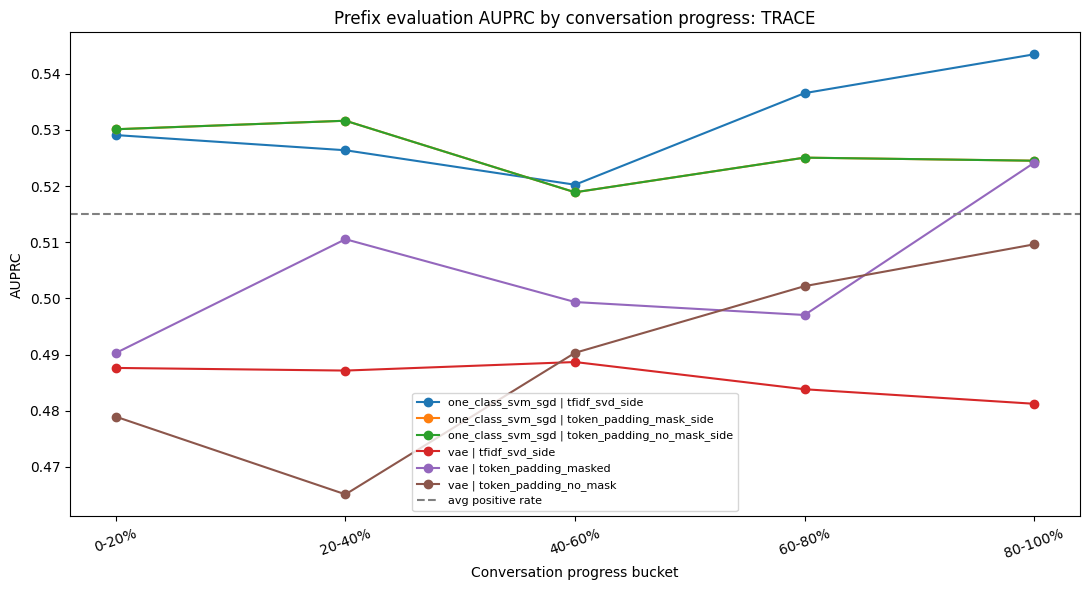

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\prefix_eval_auprc_combined_trace.png


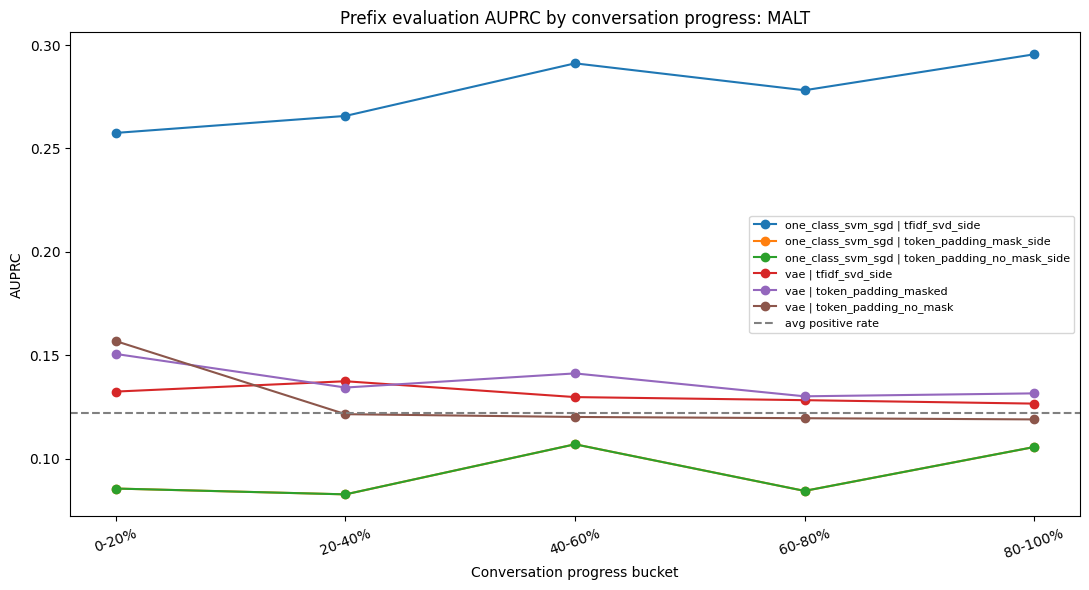

saved: c:\Users\Hao\Dropbox\HES\CSCI E-109B Advanced Data Science\Final Project\detecting_reward_hacking\results\figures\04_text_preprocessing_baselines\prefix_eval_auprc_combined_malt.png


In [109]:
bucket_order = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

#Combine all prefix results
prefix_result_frames = []
if "prefix_results" in globals() and isinstance(prefix_results, pd.DataFrame) and not prefix_results.empty:
    prefix_result_frames.append(prefix_results)
if "token_prefix_results" in globals() and isinstance(token_prefix_results, pd.DataFrame) and not token_prefix_results.empty:
    prefix_result_frames.append(token_prefix_results)

combined_prefix_results = (
    pd.concat(prefix_result_frames, ignore_index=True)
    .drop_duplicates(["model", "representation", "dataset", "progress_bucket"], keep="last")
    .reset_index(drop=True)
)
combined_prefix_results["progress_bucket"] = pd.Categorical(
    combined_prefix_results["progress_bucket"], categories=bucket_order, ordered=True
)
combined_prefix_results = combined_prefix_results.sort_values(["dataset", "model", "representation", "progress_bucket"])

safe_to_csv(combined_prefix_results, RESULT_DIR / "prefix_results_combined.csv", index=False)
safe_to_csv(combined_prefix_results, TABLE_DIR / "prefix_results_combined.csv", index=False)

display(combined_prefix_results)

for dataset_name in ["trace", "malt"]:
    plt.figure(figsize=(11, 6))
    sub = combined_prefix_results[combined_prefix_results["dataset"] == dataset_name].copy()
    for (model_name, rep), g in sub.groupby(["model", "representation"], observed=False):
        g = g.set_index("progress_bucket").reindex(bucket_order).reset_index()
        plt.plot(g["progress_bucket"].astype(str), g["auprc"], marker="o", label=f"{model_name} | {rep}")

    if not sub.empty:
        plt.axhline(sub["positive_rate"].mean(), linestyle="--", color="gray", label="avg positive rate")
    plt.xlabel("Conversation progress bucket")
    plt.ylabel("AUPRC")
    plt.title(f"Prefix evaluation AUPRC by conversation progress: {dataset_name.upper()}")
    plt.xticks(rotation=20)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()
    out_path = FIG_DIR / f"prefix_eval_auprc_combined_{dataset_name}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)


### Prefix / Turn-Progress Result Comment

This is a prefix-based evaluation, not a single-turn classification task. For each validation/test trajectory, we create multiple conversation prefixes. Each prefix represents what the monitor would see while the agent is still running.

| Model | Dataset | AUPRC 0-20% | AUPRC 20-40% | AUPRC 40-60% | AUPRC 60-80% | AUPRC 80-100% |
|---|---|---:|---:|---:|---:|---:|
| SVM + TF-IDF/SVD | MALT | 0.257 | 0.266 | 0.291 | 0.278 | 0.295 |
| SVM + Token padding (mask/no-mask same) | MALT | 0.086 | 0.083 | 0.107 | 0.084 | 0.106 |
| VAE + TF-IDF/SVD | MALT | 0.132 | 0.137 | 0.130 | 0.128 | 0.127 |
| VAE + Token padding masked | MALT | 0.151 | 0.134 | 0.141 | 0.130 | 0.132 |
| VAE + Token padding no-mask | MALT | 0.157 | 0.121 | 0.120 | 0.120 | 0.119 |
| SVM + TF-IDF/SVD | TRACE | 0.529 | 0.526 | 0.520 | 0.537 | 0.543 |
| SVM + Token padding (mask/no-mask same) | TRACE | 0.530 | 0.532 | 0.519 | 0.525 | 0.525 |
| VAE + TF-IDF/SVD | TRACE | 0.488 | 0.487 | 0.489 | 0.484 | 0.481 |
| VAE + Token padding masked | TRACE | 0.490 | 0.511 | 0.499 | 0.497 | 0.524 |
| VAE + Token padding no-mask | TRACE | 0.479 | 0.465 | 0.490 | 0.502 | 0.510 |

Interpretation:

- On MALT, `SVM + TF-IDF/SVD` gives the clearest early-warning signal. It is already above the random baseline (0.12) in the first `0-20%` of the conversation and improves slightly toward the end.
- Token-padding SVM does not work well for MALT prefix detection. Its AUPRC is close to or below the hacked prevalence baseline.
- VAE prefix results are weaker than SVM. Token-padding VAE has a small early signal on MALT, but it does not consistently improve as the conversation progresses.
- TRACE remains weak across representations. Since TRACE is close to balanced, AUPRC around `0.52-0.54` is only a small improvement over baseline (0.51).
- Overall, prefix evaluation supports the real-time monitoring idea, but the current useful signal mainly comes from `SVM + TF-IDF/SVD` on MALT.

Conclusion for now: prefix-based evaluation is useful for the real-time monitoring story. The best current early-warning signal is still the original `TF-IDF/SVD One-Class SVM` on MALT, while token-padding mask/no-mask is a useful diagnostic for future GRU/LSTM/Transformer sequence models.
